In [1]:
# Ô 1: kéo repo
!git clone https://github.com/Doan0904/K4-Track4-Day1-Neuralnetwork.git
%cd K4-Track4-Day1-Neuralnetwork/submission_MSSV/code


Cloning into 'K4-Track4-Day1-Neuralnetwork'...
remote: Enumerating objects: 52, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 52 (delta 12), reused 49 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (52/52), 11.77 MiB | 27.32 MiB/s, done.
Resolving deltas: 100% (12/12), done.
/content/K4-Track4-Day1-Neuralnetwork/submission_MSSV/code


# Lab Day 1 — Xây dựng mạng nơ-ron và thí nghiệm huấn luyện (Forest CoverType)

Notebook này chạy được từ đầu đến cuối (*Restart & Run All*) khi đặt tại `submission_<MSSV>/code/`, cùng cấp với `data/` và `scripts/` của repo (có thể ở thư mục cha, ô đầu tự tìm).
Mọi kết quả ghi vào `../figures/`, `../results/`, `../experiments.xlsx`, `../predictions_eval.csv`, `../eval_result.json`.

**Nguyên tắc:** chọn mọi cấu hình CHỈ bằng validation (20% của train, phân tầng, seed 42). Tập `eval` chỉ dùng ở Part 4, cho baseline và cấu hình cuối cùng.
Mỗi thí nghiệm: *dự đoán trước* → đổi **một** yếu tố → chạy → *đối chiếu*. Mọi lần chạy đều qua một hàm duy nhất `run_experiment(cfg, data)` (`train.py`).

**Chạy trên Colab/Kaggle:** tải nguyên repo (có `data/`, `scripts/`, `submission_<MSSV>/`) lên Drive hoặc giải nén vào `/content`, rồi `%cd` vào `submission_<MSSV>/code` trước khi chạy ô đầu. Bật GPU (T4). Nếu Colab ngắt giữa chừng, chạy lại: các lần chạy đã có `results/<exp_id>.json` sẽ được nạp lại (cờ `RESUME`), riêng baseline/cấu hình cuối luôn chạy lại vì cần trọng số.

In [2]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, time, subprocess, tempfile
import numpy as np, pandas as pd, torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import Image, display

sys.path.insert(0, os.getcwd())                       # để import data.py, model.py, ... trong code/
QUICK = bool(os.environ.get("LAB_QUICK"))             # chỉ để kiểm tra nhanh code; khi nộp phải là False
RESUME = True                                         # nạp lại results/<exp_id>.json nếu cấu hình không đổi

def find_repo_root():
    d = os.path.abspath(os.getcwd())
    for _ in range(6):                                # đi lên tối đa 6 cấp tìm thư mục có data/ và scripts/
        if os.path.exists(os.path.join(d, "data", "covtype.csv.gz")) and os.path.exists(os.path.join(d, "scripts", "split_data.py")):
            return d
        d = os.path.dirname(d)
    raise FileNotFoundError("Không thấy thư mục gốc repo (chứa data/ và scripts/). Hãy %cd vào submission_<MSSV>/code.")

REPO_ROOT = find_repo_root()                          # = "../.." khi chạy từ submission_<MSSV>/code
OUT_DIR = ".." if os.path.basename(os.getcwd()) == "code" else "./out"
if QUICK: OUT_DIR = "./out_quick"

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("torch", torch.__version__, "| device:", device, "|", torch.cuda.get_device_name(0) if device == "cuda" else "")
print("REPO_ROOT =", REPO_ROOT, "| OUT_DIR =", OUT_DIR, "| QUICK =", QUICK)
os.makedirs(f"{OUT_DIR}/figures", exist_ok=True)
os.makedirs(f"{OUT_DIR}/results", exist_ok=True)

from data import prepare_data
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import (DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval,
                   run_evaluate_script, macro_f1_from_confusion)
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx
T_START = time.time()

torch 2.11.0+cu130 | device: cuda | Tesla T4
REPO_ROOT = /content/K4-Track4-Day1-Neuralnetwork | OUT_DIR = .. | QUICK = False


## Part 0 — Dữ liệu
Chia sẵn bằng metadata: chạy `scripts/split_data.py` từ thư mục gốc repo (tạo `data/processed/train.npz`, `eval.npz`).
Sau đó tách validation từ train (20%, phân tầng, seed 42), chuẩn hoá 10 cột số bằng thống kê của phần train còn lại, đưa toàn bộ lên device một lần.

In [3]:
r = subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, check=True, capture_output=True, text=True)
print(r.stdout)
data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=f"{REPO_ROOT}/data/processed")

train: X (464809, 54) float32, y (464809,) int64, nhãn 0..6 -> data/processed/train.npz
eval : X (116203, 54) float32, y (116203,) int64, nhãn 0..6 -> data/processed/eval.npz

lớp   train(%)   eval(%)
  0    36.461    36.460
  1    48.760    48.760
  2     6.154     6.154
  3     0.473     0.472
  4     1.634     1.634
  5     2.989     2.989
  6     3.530     3.530

đoán luôn lớp đa số (lớp 1) cho accuracy trên eval = 0.4876

X_tr (371847, 54) | X_val (92962, 54) | X_eval (116203, 54)
'luôn đoán lớp đa số' (lớp 1) trên val: acc = 0.4876


In [4]:
# Kiểm tra Part 0
Xtr, ytr, Xva, yva, Xev, yev = (data[k].cpu() for k in ("X_tr", "y_tr", "X_val", "y_val", "X_eval", "y_eval"))
assert (len(Xtr), len(Xva), len(Xev)) == (371_847, 92_962, 116_203)
prop = pd.DataFrame({n: np.bincount(y.numpy(), minlength=7) / len(y) for n, y in (("train", ytr), ("val", yva), ("eval", yev))})
print("Tỉ lệ lớp:\n", prop.round(4).T.to_string())
m, s = Xtr[:, :10].mean(0), Xtr[:, :10].std(0)
print(f"\n10 cột số trên X_tr: |mean| lớn nhất = {m.abs().max():.2e}, std trong [{s.min():.4f}, {s.max():.4f}]")
assert m.abs().max() < 1e-3 and (s - 1).abs().max() < 1e-3
print("X_val  mean/std cột số:", f"{Xva[:, :10].mean():.4f} / {Xva[:, :10].std():.4f}", "(≠ 0/1 chính xác vì dùng thống kê của train)")
assert set(torch.unique(Xtr[:, 10:]).tolist()) <= {0.0, 1.0}                      # 44 cột nhị phân giữ nguyên
print("accuracy 'luôn đoán lớp đa số' trên val =", round(data["majority_val_acc"], 4))

Tỉ lệ lớp:
             0       1       2       3       4       5       6
train  0.3646  0.4876  0.0615  0.0047  0.0163  0.0299  0.0353
val    0.3646  0.4876  0.0615  0.0047  0.0163  0.0299  0.0353
eval   0.3646  0.4876  0.0615  0.0047  0.0163  0.0299  0.0353

10 cột số trên X_tr: |mean| lớn nhất = 3.21e-04, std trong [0.9999, 1.0001]
X_val  mean/std cột số: 0.0015 / 1.0009 (≠ 0/1 chính xác vì dùng thống kê của train)
accuracy 'luôn đoán lớp đa số' trên val = 0.4876


## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
Quy định: `M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model, ReLU, bias ở mọi lớp, dropout (nếu có) sau ReLU.

In [5]:
# 1) Dựng M-base, assert số tham số, shape sau từng lớp
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
assert count_params(model) == EXPECTED_PARAMS[(256, 128)]
for hid, n in EXPECTED_PARAMS.items():
    assert count_params(MLP(hid)) == n, hid
print(model, "\nsố tham số M-base =", count_params(model), "(M-wide, M-deep cũng khớp bảng)")
h = torch.randn(8, 54, device=device)
with torch.no_grad():
    print("input", tuple(h.shape))
    for layer in model.net:
        h = layer(h); print(f"  {layer.__class__.__name__:7s} -> {tuple(h.shape)}")
assert h.shape == (8, 7)
# He thật sự được áp dụng? std(W1) kỳ vọng sqrt(2/54); mặc định của nn.Linear thì khác
print("std W1 (He)      =", round(model.net[0].weight.std().item(), 4), "| sqrt(2/54) =", round((2 / 54) ** .5, 4))
print("std W1 (default) =", round(MLP((256, 128), init="default").net[0].weight.std().item(), 4), "(≠ He, không dùng làm baseline)")

MLP(
  (net): Sequential(
    (0): Linear(in_features=54, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=7, bias=True)
  )
) 
số tham số M-base = 47879 (M-wide, M-deep cũng khớp bảng)
input (8, 54)
  Linear  -> (8, 256)
  ReLU    -> (8, 256)
  Linear  -> (8, 128)
  ReLU    -> (8, 128)
  Linear  -> (8, 7)
std W1 (He)      = 0.1919 | sqrt(2/54) = 0.1925
std W1 (default) = 0.0783 (≠ He, không dùng làm baseline)


In [6]:
# 2) Loss bước 0 trên val (eval mode) ≈ ln 7; cũng đối chiếu macro-F1 tự tính với sklearn
from sklearn.metrics import f1_score
set_seed(0)
m0 = MLP((256, 128), 0.0, "he").to(device)
ev0 = evaluate(m0, data["X_val"], data["y_val"], "ce")
print(f"loss bước 0 (val) = {ev0['loss']:.4f} | ln 7 = {np.log(7):.4f} | chênh = {ev0['loss'] - np.log(7):+.4f}")
p = predict(m0, data["X_val"]).cpu().numpy()
f1_sk = f1_score(data["y_val"].cpu().numpy(), p, average="macro")
print(f"macro-F1 tự tính = {ev0['macro_f1']:.6f} | sklearn = {f1_sk:.6f}")
assert abs(ev0["macro_f1"] - f1_sk) < 1e-9

loss bước 0 (val) = 2.2073 | ln 7 = 1.9459 | chênh = +0.2614
macro-F1 tự tính = 0.056598 | sklearn = 0.056598


loss: bước 0 = 2.1983 -> bước 100 = 0.0005 -> bước 500 = 0.00016 | acc 20 mẫu = 1.00


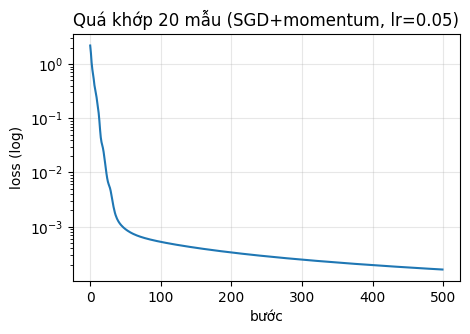

In [7]:
# 3) Quá khớp 20 mẫu (tắt dropout): loss phải về gần 0, accuracy 100%
set_seed(0)
idx = torch.randperm(len(data["X_tr"]), generator=torch.Generator().manual_seed(0))[:20].to(device)
xs, ys = data["X_tr"][idx], data["y_tr"][idx]
mo = MLP((256, 128), 0.0, "he").to(device)
opt = build_optimizer("sgd_momentum", mo.parameters(), lr=0.05)
losses = []
for step in range(500):
    mo.train(); loss = F.cross_entropy(mo(xs), ys)
    opt.zero_grad(); loss.backward(); opt.step(); losses.append(loss.item())
acc20 = (mo(xs).argmax(1) == ys).float().mean().item()
print(f"loss: bước 0 = {losses[0]:.4f} -> bước 100 = {losses[100]:.4f} -> bước 500 = {losses[-1]:.5f} | acc 20 mẫu = {acc20:.2f}")
assert losses[-1] < 0.05 and acc20 == 1.0
plt.figure(figsize=(5, 3.2)); plt.semilogy(losses); plt.xlabel("bước"); plt.ylabel("loss (log)")
plt.title("Quá khớp 20 mẫu (SGD+momentum, lr=0.05)"); plt.grid(alpha=.3); plt.show()

In [8]:
# 4) Gradient có chảy tới mọi tham số không? (một lô val, một lần backward)
mg = MLP((256, 128), 0.0, "he").to(device); mg.train()
loss = F.cross_entropy(mg(data["X_val"][:512]), data["y_val"][:512]); loss.backward()
for (name, p_) in mg.named_parameters():
    assert p_.grad is not None and p_.grad.norm() > 0, name
    print(f"{name:12s} shape {str(tuple(p_.shape)):11s} ‖grad‖ = {p_.grad.norm().item():.4f}")
print("OK: mọi tham số có gradient khác 0")

net.0.weight shape (256, 54)   ‖grad‖ = 0.4863
net.0.bias   shape (256,)      ‖grad‖ = 0.3139
net.2.weight shape (128, 256)  ‖grad‖ = 1.9510
net.2.bias   shape (128,)      ‖grad‖ = 0.4261
net.4.weight shape (7, 128)    ‖grad‖ = 1.8484
net.4.bias   shape (7,)        ‖grad‖ = 0.5322
OK: mọi tham số có gradient khác 0


**Nhận xét Part 1:** loss bước 0 (val, seed 0) đo được = **2.2073**, lớn hơn ln 7 = 1.946 khoảng 0.26. Đây *không* phải lỗi nhãn/softmax đôi: với khởi tạo He (Var = 2/n_in) logits ở bước 0 có độ lệch chuẩn ≈ 0.6 (đo ở `base-s1`: 0.593, xem bảng nhóm `init`), nên phân phối softmax không còn đều và loss kỳ vọng lớn hơn ln 7 (xấp xỉ thô ln 7 + σ²/2). Loss bước 0 cũng phụ thuộc seed (2.269 / 1.978 / 1.901 ở `base-s1/2/3`), còn `zeros` và `normal` cho đúng ≈ 1.946. Hai phép thử còn lại đều qua: quá khớp 20 mẫu đưa loss từ 2.198 xuống 0.0005 ở bước 100 và 0.00016 ở bước 500 (accuracy 100%), và mọi tham số có gradient khác 0 (‖grad‖ từ 0.31 đến 1.95). macro-F1 tự tính khớp `sklearn` đến 1e-9.

## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` nhận một dict cấu hình, trả về lịch sử + tóm tắt (+ `best_state`, trọng số của epoch có val loss thấp nhất).
Baseline (`M-base`): SGD + momentum 0.9, cross-entropy, He init, batch 512, **20 epoch**, FP32, không dropout, không clip.
`lr` chọn bằng **val**: quét `lr ∈ {0.003, 0.01, 0.03, 0.1, 0.3}` với seed 1 (đây cũng là thí nghiệm nhóm `hparam`).

In [9]:
EPOCHS = 2 if QUICK else 20
BASE_CFG = {**DEFAULT_CFG, "epochs": EPOCHS}          # lr đặt sau khi quét
RESULTS, NOTES = {}, {}                               # exp_id -> kết quả (theo thứ tự chạy) / ghi chú cho bảng
SAME_KEYS = ("loss", "optimizer", "lr", "weight_decay", "momentum", "batch", "epochs", "hidden", "dropout",
             "init", "clip_norm", "precision", "scheduler", "seed")
_norm = lambda v: tuple(v) if isinstance(v, (list, tuple)) else v

def run(cfg, need_state=False, note=""):
    """Chạy (hoặc nạp lại) một thí nghiệm, lưu JSON + ảnh figures/<exp_id>.png, in một dòng tóm tắt."""
    cfg = {**BASE_CFG, **cfg}
    eid, path = cfg["exp_id"], f"{OUT_DIR}/results/{cfg['exp_id']}.json"
    res = None
    if RESUME and not need_state and os.path.exists(path):
        old = json.load(open(path))
        if all(_norm(old["cfg"].get(k)) == _norm(cfg.get(k)) for k in SAME_KEYS):
            old["cfg"]["hidden"] = tuple(old["cfg"]["hidden"]); res = old; tag = "(nạp lại)"
    if res is None:
        res = run_experiment(cfg, data); save_result(res, f"{OUT_DIR}/results"); tag = ""
    plot_run(res, f"{OUT_DIR}/figures/{eid}.png")
    RESULTS[eid] = res
    if note: NOTES[eid] = note
    s = res["summary"]
    print(f"{eid:26s} best_ep={s['best_epoch']!s:>4} val_loss={s['best_val_loss']:.4f} acc={s['val_acc']:.4f} "
          f"F1={s['val_macro_f1']:.4f} | {s['time_per_epoch_s']:.1f}s/ep"
          f"{' | DIVERGED' if s['diverged'] else ''} {tag}")
    return res

def table(results, ref=None):
    """Bảng so sánh ngắn; ref = trung bình val_macro_f1 baseline và ngưỡng 2σ (nếu đã có)."""
    rows = []
    for r in results:
        c, s = r["cfg"], r["summary"]
        d = dict(exp_id=c["exp_id"], opt=c["optimizer"], lr=c["lr"], best_ep=s["best_epoch"], val_loss=s["best_val_loss"],
                 val_acc=s["val_acc"], val_f1=s["val_macro_f1"], t_ep=s["time_per_epoch_s"], diverged=s["diverged"])
        if ref: d["ΔF1 vs base"] = s["val_macro_f1"] - ref[0]; d["> 2σ?"] = "Có" if abs(d["ΔF1 vs base"]) > ref[1] else "Không"
        rows.append(d)
    return pd.DataFrame(rows).round(4).to_string(index=False)

# khởi động GPU (không lưu) để thời gian/epoch của lần chạy đầu không bị lệch bởi khởi tạo CUDA
_ = run_experiment({**BASE_CFG, "exp_id": "warmup", "lr": 0.03, "epochs": 1}, data)

In [10]:
# Quét lr của baseline (SGD+momentum 0.9), chọn bằng val macro-F1
sweep = [run({"exp_id": f"lr-sgdm-{lr:g}", "group": "hparam", "lr": lr, "seed": 1,
              "description": f"Quét lr baseline: SGD+momentum lr={lr:g}"},
             note="Quét lr bằng val để chọn lr baseline") for lr in (0.003, 0.01, 0.03, 0.1, 0.3)]
LR = max(sweep, key=lambda r: np.nan_to_num(r["summary"]["val_macro_f1"], nan=-1))["cfg"]["lr"]
print("\n" + table(sweep)); print(f"\n=> lr baseline chọn bằng VAL (macro-F1 cao nhất) = {LR:g}")
BASE_CFG["lr"] = LR

lr-sgdm-0.003              best_ep=  20 val_loss=0.4197 acc=0.8254 F1=0.6643 | 1.2s/ep 
lr-sgdm-0.01               best_ep=  20 val_loss=0.3100 acc=0.8757 F1=0.7621 | 1.2s/ep 
lr-sgdm-0.03               best_ep=  18 val_loss=0.2670 acc=0.8930 F1=0.8202 | 1.2s/ep 
lr-sgdm-0.1                best_ep=  18 val_loss=0.2393 acc=0.9035 F1=0.8434 | 1.4s/ep 
lr-sgdm-0.3                best_ep=  20 val_loss=0.2263 acc=0.9127 F1=0.8599 | 1.3s/ep 

       exp_id          opt    lr  best_ep  val_loss  val_acc  val_f1   t_ep  diverged
lr-sgdm-0.003 sgd_momentum 0.003       20    0.4197   0.8254  0.6643 1.2344     False
 lr-sgdm-0.01 sgd_momentum 0.010       20    0.3100   0.8757  0.7621 1.2243     False
 lr-sgdm-0.03 sgd_momentum 0.030       18    0.2670   0.8930  0.8202 1.2307     False
  lr-sgdm-0.1 sgd_momentum 0.100       18    0.2393   0.9035  0.8434 1.3654     False
  lr-sgdm-0.3 sgd_momentum 0.300       20    0.2263   0.9127  0.8599 1.2644     False

=> lr baseline chọn bằng VAL (macro-F1 cao

base-s1                    best_ep=  20 val_loss=0.2263 acc=0.9127 F1=0.8599 | 1.2s/ep 
base-s2                    best_ep=  19 val_loss=0.2151 acc=0.9150 F1=0.8653 | 1.2s/ep 
base-s3                    best_ep=  19 val_loss=0.2215 acc=0.9104 F1=0.8596 | 1.2s/ep 

val macro-F1 = 0.8616 ± 0.0032 | val acc = 0.9127 ± 0.0023 | ngưỡng nhiễu 2σ = 0.0064
mốc 'đoán đa số': acc 0.4876, macro-F1 ≈ 0.094 -> baseline vượt mốc: True
kiểm tra tái lập: lr-sgdm-0.3 (seed 1) F1 = 0.8599 vs base-s1 F1 = 0.8599


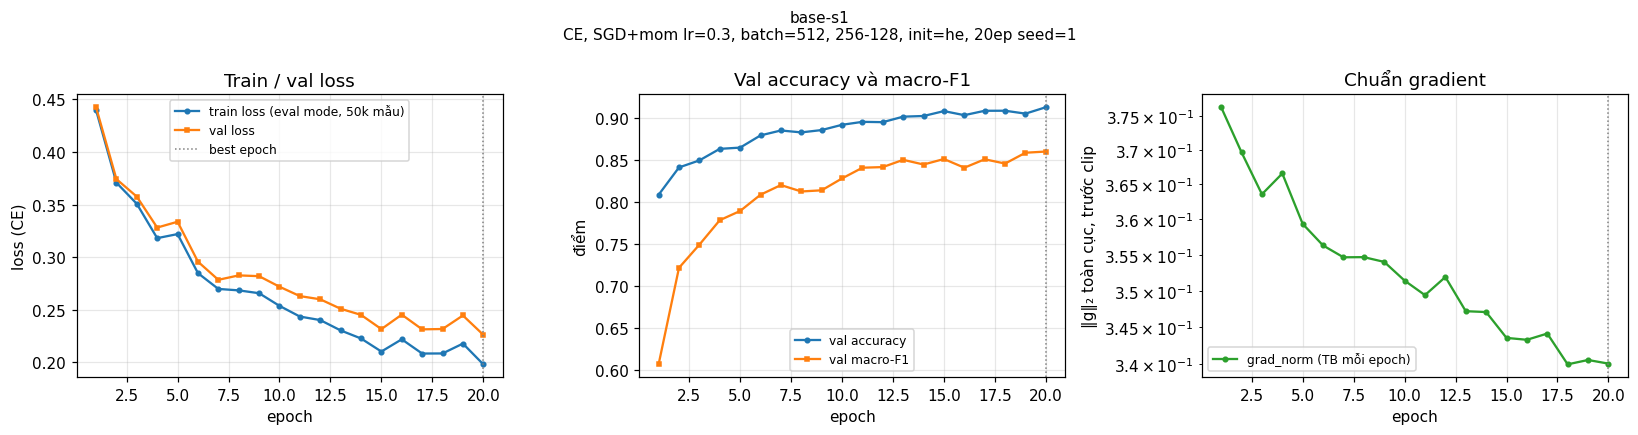

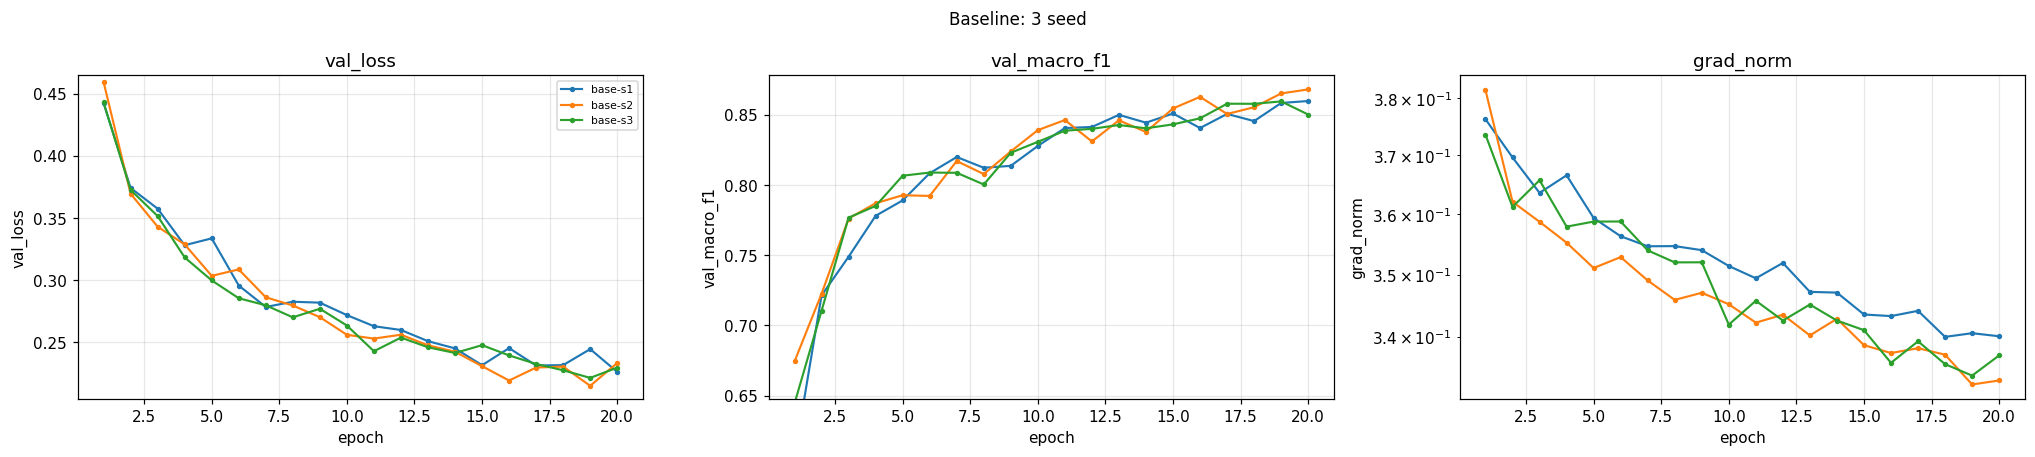

In [11]:
# Baseline với 3 seed (cần best_state để dự đoán eval ở Part 4)
base = [run({"exp_id": f"base-s{s}", "group": "baseline", "seed": s, "description": f"Baseline M-base, seed {s}"},
            need_state=True) for s in (1, 2, 3)]
f1s, accs = np.array([r["summary"]["val_macro_f1"] for r in base]), np.array([r["summary"]["val_acc"] for r in base])
F1_MEAN, SIGMA = f1s.mean(), f1s.std(ddof=1)          # ddof=1 giống STDEV của Excel (sheet Seeds)
NOISE = 2 * SIGMA; REF = (F1_MEAN, NOISE)
print(f"\nval macro-F1 = {F1_MEAN:.4f} ± {SIGMA:.4f} | val acc = {accs.mean():.4f} ± {accs.std(ddof=1):.4f} | ngưỡng nhiễu 2σ = {NOISE:.4f}")
print(f"mốc 'đoán đa số': acc {data['majority_val_acc']:.4f}, macro-F1 ≈ 0.094 -> baseline vượt mốc: {accs.min() > data['majority_val_acc']}")
b1 = next(r for r in sweep if r["cfg"]["lr"] == LR)["summary"]["val_macro_f1"]
print(f"kiểm tra tái lập: lr-sgdm-{LR:g} (seed 1) F1 = {b1:.4f} vs base-s1 F1 = {base[0]['summary']['val_macro_f1']:.4f}")
plot_compare(base, ["val_loss", "val_macro_f1", "grad_norm"], f"{OUT_DIR}/figures/compare_baseline.png", "Baseline: 3 seed")
display(Image(f"{OUT_DIR}/figures/base-s1.png")); display(Image(f"{OUT_DIR}/figures/compare_baseline.png"))

**Nhận xét baseline:** cả train loss (đo ở eval mode) và val loss vẫn đang giảm ở epoch 20 (best epoch = 20, 19, 19), khoảng cách val − train chỉ 0.028 và val macro-F1 vẫn tăng (0.61 ở epoch 1 → 0.86), nên baseline **chưa hội tụ và chưa quá khớp** (thiếu khớp/thiếu thời gian). `grad_norm` giảm chậm từ 0.376 xuống 0.340, không có gai. val accuracy 0.9127 ≫ mốc đoán đa số 0.4876. Độ nhiễu giữa 3 seed: val macro-F1 = 0.8616 ± 0.0032 (ngưỡng 2σ = 0.0064), val acc = 0.9127 ± 0.0023; σ ước lượng từ 3 seed nên chỉ là số thô. Lưu ý: lr chọn được (0.3) nằm đúng ở mép trên của lưới quét, nên lr tối ưu thực sự có thể lớn hơn.

## Part 3 — Thí nghiệm
Mỗi nhóm: **dự đoán trước (viết trước khi chạy)** → chạy → bảng + ảnh chồng `compare_<nhóm>.png` → **đối chiếu**. Mỗi lần chỉ đổi một yếu tố so với `base-s1` (cùng split, cùng 20 epoch, seed 1), trừ khi ghi rõ.
Cột `ΔF1 vs base` = val macro-F1 − trung bình baseline; "> 2σ?" cho biết chênh lệch có vượt ngưỡng nhiễu seed không.

### Nhóm `hparam` — lr, batch size, độ rộng, độ sâu
**Dự đoán trước (đã viết trước khi chạy):**
- *lr:* với 20 epoch và mạng chưa quá khớp, lr quá nhỏ (0.003) hội tụ chậm nên macro-F1 thấp; lr quá lớn (0.3) bắt đầu dao động; tốt nhất ở giữa (0.03–0.1).
- *batch:* batch 128 cho gấp 4 lần số bước cập nhật trong cùng 20 epoch → F1 cao hơn nhưng mỗi epoch chậm hơn nhiều. Batch 2048 (cùng lr) chỉ còn 1/4 số bước → chưa hội tụ, F1 thấp hơn; tăng lr ×4 (quy tắc tăng lr theo lô) bù lại phần lớn.
- *độ rộng/sâu:* mô hình đang *thiếu khớp* (underfit) nên `M-wide` (3.4× tham số) cải thiện rõ; `M-deep` cải thiện ít hơn.

hp-batch128                best_ep=  18 val_loss=0.3202 acc=0.8798 F1=0.7965 | 4.8s/ep 
hp-batch2048               best_ep=  18 val_loss=0.2460 acc=0.9011 F1=0.8375 | 0.3s/ep 
hp-batch2048-lr4x          best_ep=  11 val_loss=1.2052 acc=0.4876 F1=0.0936 | 0.3s/ep 
hp-wide                    best_ep=  20 val_loss=0.1936 acc=0.9237 F1=0.8749 | 1.2s/ep 
hp-deep                    best_ep=  18 val_loss=0.2242 acc=0.9127 F1=0.8434 | 1.4s/ep 

           exp_id          opt    lr  best_ep  val_loss  val_acc  val_f1   t_ep  diverged  ΔF1 vs base > 2σ?
    lr-sgdm-0.003 sgd_momentum 0.003       20    0.4197   0.8254  0.6643 1.2344     False      -0.1973    Có
     lr-sgdm-0.01 sgd_momentum 0.010       20    0.3100   0.8757  0.7621 1.2243     False      -0.0995    Có
     lr-sgdm-0.03 sgd_momentum 0.030       18    0.2670   0.8930  0.8202 1.2307     False      -0.0414    Có
      lr-sgdm-0.1 sgd_momentum 0.100       18    0.2393   0.9035  0.8434 1.3654     False      -0.0181    Có
      lr-sgdm-

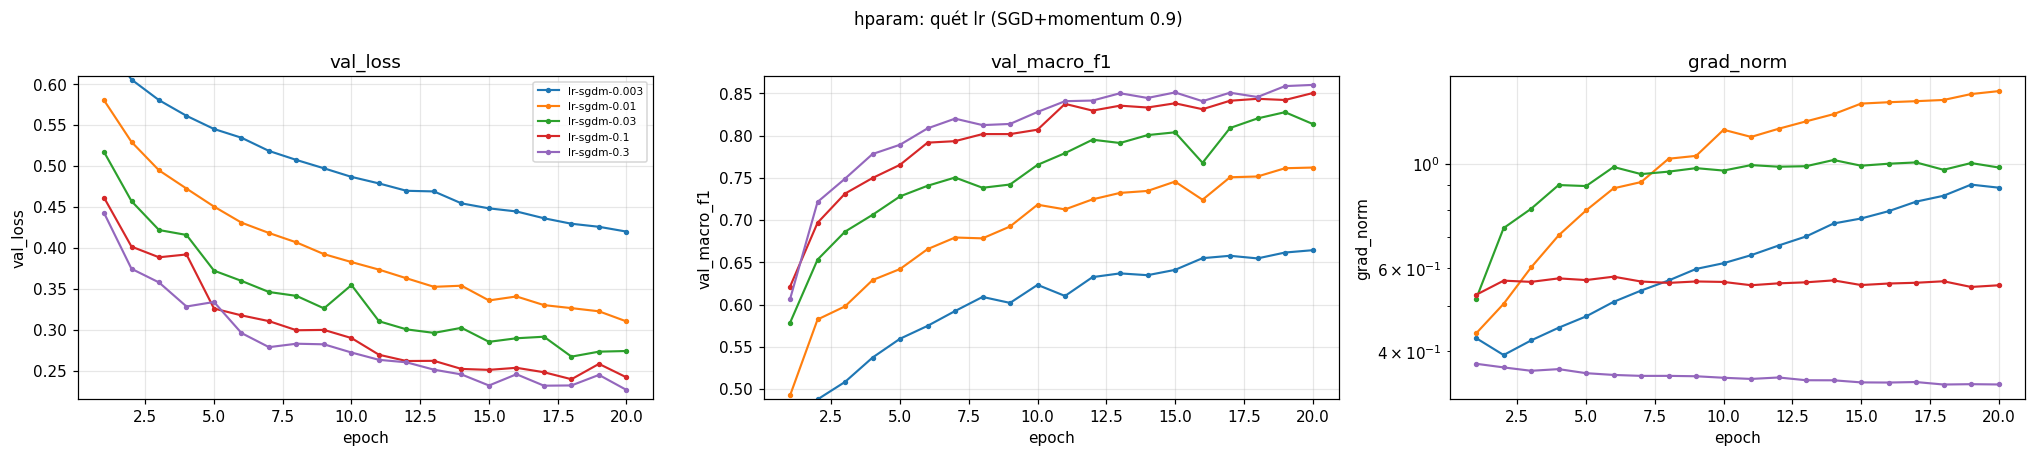

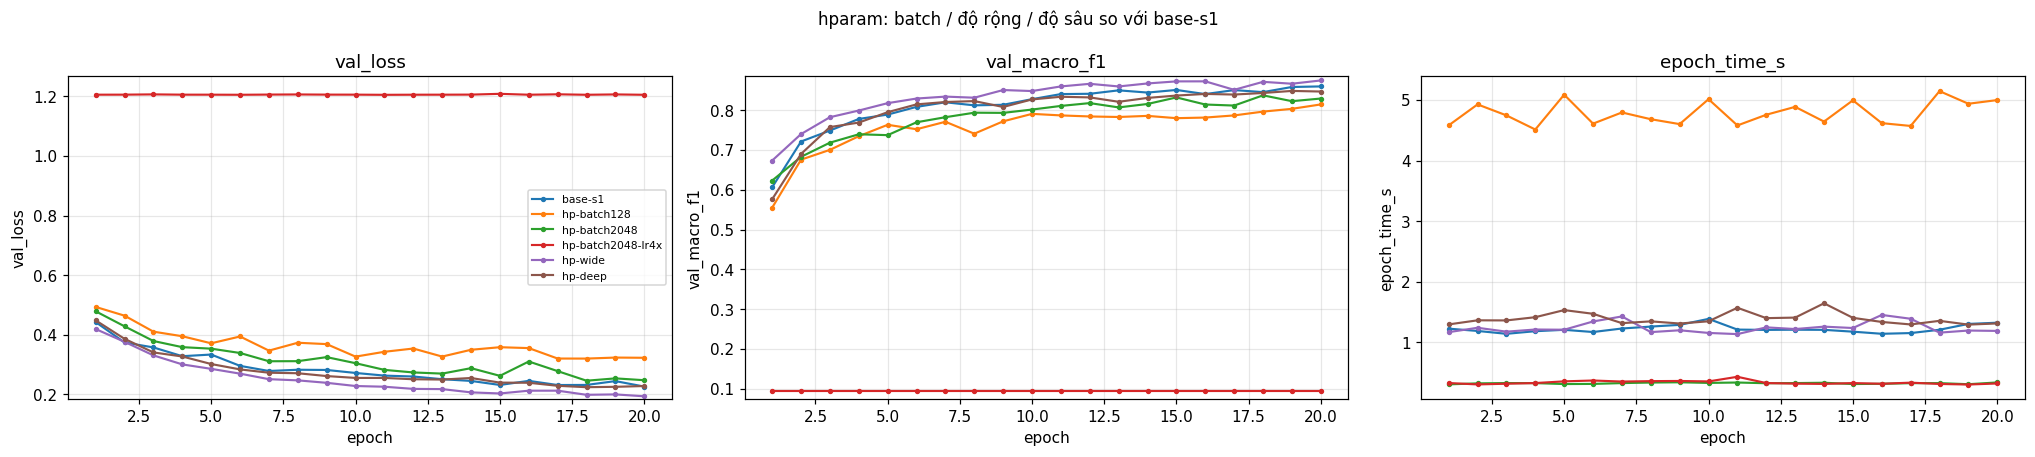

In [12]:
hp = [run({"exp_id": "hp-batch128", "group": "hparam", "batch": 128, "description": "batch 128 (4x số bước), lr giữ nguyên"},
          note="Dự đoán: nhiều bước hơn -> F1 cao hơn, chậm hơn mỗi epoch"),
      run({"exp_id": "hp-batch2048", "group": "hparam", "batch": 2048, "description": "batch 2048 (1/4 số bước), lr giữ nguyên"},
          note="Dự đoán: ít bước -> chưa hội tụ, F1 thấp hơn"),
      run({"exp_id": "hp-batch2048-lr4x", "group": "hparam", "batch": 2048, "lr": LR * 4,
           "description": "batch 2048 và lr x4 (quy tắc tăng lr theo lô)"}, note="Đổi 2 yếu tố (batch và lr) có chủ đích; dự đoán: bù lại phần lớn"),
      run({"exp_id": "hp-wide", "group": "hparam", "hidden": (512, 256), "description": "M-wide 54-512-256-7"},
          note="Dự đoán: underfit -> rộng hơn tốt hơn"),
      run({"exp_id": "hp-deep", "group": "hparam", "hidden": (256, 128, 64), "description": "M-deep 54-256-128-64-7"},
          note="Dự đoán: cải thiện ít hơn M-wide")]
print("\n" + table(sweep + hp, REF))
plot_compare(sweep, ["val_loss", "val_macro_f1", "grad_norm"], f"{OUT_DIR}/figures/compare_hparam-lr.png", "hparam: quét lr (SGD+momentum 0.9)")
plot_compare([base[0]] + hp, ["val_loss", "val_macro_f1", "epoch_time_s"], f"{OUT_DIR}/figures/compare_hparam.png", "hparam: batch / độ rộng / độ sâu so với base-s1")
display(Image(f"{OUT_DIR}/figures/compare_hparam-lr.png")); display(Image(f"{OUT_DIR}/figures/compare_hparam.png"))

**Đối chiếu `hparam`:**
- *lr:* val macro-F1 tăng đơn điệu theo lr (0.664 → 0.762 → 0.820 → 0.843 → 0.860 cho 0.003 → 0.3). Khớp dự đoán là lr nhỏ thì hội tụ chậm, nhưng **sai ở chỗ không thấy dao động ở lr lớn nhất**: tối ưu nằm ngoài lưới (≥ 0.3). Hạn chế đã nêu ở trên. (Các lần chạy lr = 3 và 9 ở nhóm clipping đều sụp đổ, nên tối ưu nằm giữa 0.3 và 3.)
- *batch:* `hp-batch2048` (1/4 số bước) thấp hơn baseline 0.024 (> 2σ), khớp dự đoán; thời gian/epoch giảm 3.8× (0.32 s so với 1.22 s). `hp-batch128` thì **ngược dự đoán**: 0.7965, thấp hơn 0.065 dù có 4× số bước, và chậm 3.9× (4.78 s/epoch). Giải thích phù hợp với số đo nhưng chưa kiểm chứng: cùng lr 0.3, lô nhỏ nhiễu hơn (grad_norm trung vị 0.435 so với 0.347) nên lr tối ưu dịch xuống khi giảm batch; cần chạy batch 128 với lr nhỏ hơn để xác nhận. `hp-batch2048-lr4x` (lr 1.2) sụp về mốc đoán đa số (F1 = 0.0936): quy tắc tăng lr ×k không dùng được khi lr gốc đã sát ngưỡng mất ổn định và không có khởi động.
- *độ rộng/sâu:* `hp-wide` tăng +0.0133 so với trung bình baseline (> 2σ = 0.0064), khớp dự đoán underfit. `hp-deep` thấp hơn baseline 0.018, **ngược dự đoán**; có thể lr 0.3 quá lớn cho mạng sâu hơn, nhưng chưa thử lr khác (một seed).

### Nhóm `loss` — cross-entropy vs MSE trên one-hot
**Dự đoán trước:** gradient của CE theo logit là `softmax(z) − y` (giới hạn trong [−1, 1], lớn khi dự đoán sai nặng, không bão hoà); của MSE (`mean` trên mọi phần tử, B×7) là `2(z − y)/7`, nhỏ hơn ~3.5 lần trên mỗi phần tử và không "đẩy" xác suất lớp đúng mạnh khi sai nặng. Nên ở cùng lr, MSE học chậm hơn và macro-F1 thấp hơn (nhất là lớp hiếm); tăng lr (×3, ×10) sẽ bù một phần. Loss CE và MSE khác thang đo nên so bằng accuracy/macro-F1/tốc độ hội tụ, không so loss.

loss-mse-lr0.3             best_ep=  20 val_loss=0.0275 acc=0.8812 F1=0.7735 | 1.3s/ep 
loss-mse-lr0.9             best_ep=  19 val_loss=0.0325 acc=0.8596 F1=0.7489 | 1.3s/ep 
loss-mse-lr3               best_ep=  18 val_loss=0.0891 acc=0.4876 F1=0.0936 | 1.3s/ep 
        exp_id          opt  lr  best_ep  val_loss  val_acc  val_f1   t_ep  diverged  ΔF1 vs base > 2σ?
       base-s1 sgd_momentum 0.3       20    0.2263   0.9127  0.8599 1.2188     False      -0.0017 Không
loss-mse-lr0.3 sgd_momentum 0.3       20    0.0275   0.8812  0.7735 1.2778     False      -0.0880    Có
loss-mse-lr0.9 sgd_momentum 0.9       19    0.0325   0.8596  0.7489 1.2841     False      -0.1127    Có
  loss-mse-lr3 sgd_momentum 3.0       18    0.0891   0.4876  0.0936 1.2716     False      -0.7679    Có


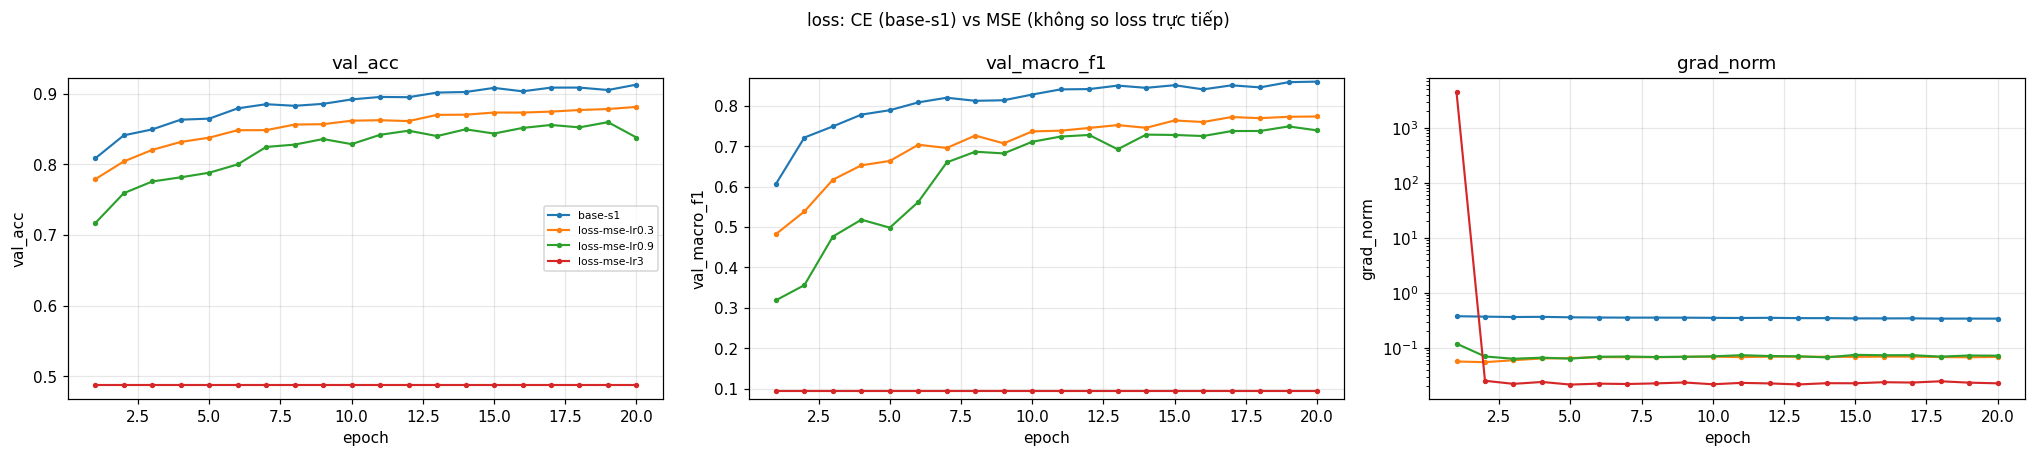

In [13]:
ls = [run({"exp_id": f"loss-mse-lr{LR * m:g}", "group": "loss", "loss": "mse", "lr": LR * m,
           "description": f"MSE trên one-hot (mean trên B*7 phần tử), lr={LR * m:g}"},
          note="Dự đoán: MSE chậm/kém hơn CE ở cùng lr; lr lớn hơn bù một phần") for m in (1, 3, 10)]
print(table([base[0]] + ls, REF))
plot_compare([base[0]] + ls, ["val_acc", "val_macro_f1", "grad_norm"], f"{OUT_DIR}/figures/compare_loss.png", "loss: CE (base-s1) vs MSE (không so loss trực tiếp)")
display(Image(f"{OUT_DIR}/figures/compare_loss.png"))

**Đối chiếu `loss`:** MSE kém hơn CE rõ rệt: macro-F1 0.7735 (lr 0.3) so với 0.8599, thấp hơn 0.088 (≫ 2σ = 0.0064), khớp dự đoán. Số đo ủng hộ cơ chế gradient nhỏ: `grad_norm` trung vị của MSE chỉ 0.065 so với 0.347 của CE ở cùng lr; ở bước 0 gradient theo logit của lớp đúng là ≈ −0.86 (CE) so với ≈ −0.29 (MSE, 2(z−1)/7 với z ≈ 0). Phần dự đoán **"tăng lr bù được" sai**: lr 0.9 còn tệ hơn (0.7489) và lr 3 sụp về mốc đoán đa số (0.0936); MSE tốt nhất ở lr thấp nhất đã thử (0.3), nên chưa biết lr dưới 0.3 có tốt hơn không. Không so loss CE và MSE trực tiếp (khác thang đo); chưa đo F1 riêng lớp hiếm cho MSE nên không kết luận về lớp hiếm.

### Nhóm `optimizer` — SGD, SGD+momentum, Adam, AdamW (mỗi bộ thử 3 lr)
**Dự đoán trước:** Adam/AdamW chia bước theo độ lớn gradient từng tham số nên ít nhạy với thang đặc trưng và với lr hơn, và trong 20 epoch hội tụ nhanh hơn SGD+momentum → val macro-F1 ở lr tốt nhất của Adam cao hơn SGD+momentum. AdamW với `weight_decay=0.01` gần như trùng Adam (suy giảm tách riêng quá nhỏ ở 20 epoch). SGD thuần (không momentum) chậm hơn khoảng 10× so với SGD+momentum 0.9 ở cùng lr (bước hiệu dụng `lr/(1−μ)`), nên cần lr lớn hơn. Kết luận phải dựa trên lr tốt nhất của mỗi bộ, không phải một lr duy nhất.

opt-sgd-lr0.3              best_ep=  18 val_loss=0.2807 acc=0.8868 F1=0.8177 | 1.2s/ep 
opt-sgd-lr0.9              best_ep=  18 val_loss=0.2574 acc=0.8975 F1=0.8236 | 1.2s/ep 
opt-sgd-lr3                best_ep=  18 val_loss=0.3364 acc=0.8695 F1=0.6534 | 1.2s/ep 
opt-adam-lr0.0003          best_ep=  20 val_loss=0.3127 acc=0.8729 F1=0.7878 | 1.4s/ep 
opt-adam-lr0.001           best_ep=  18 val_loss=0.2443 acc=0.9021 F1=0.8446 | 1.4s/ep 
opt-adam-lr0.003           best_ep=  19 val_loss=0.2169 acc=0.9136 F1=0.8702 | 1.4s/ep 
opt-adamw-lr0.0003         best_ep=  20 val_loss=0.3156 acc=0.8718 F1=0.7848 | 1.4s/ep 
opt-adamw-lr0.001          best_ep=  18 val_loss=0.2487 acc=0.9002 F1=0.8403 | 1.4s/ep 
opt-adamw-lr0.003          best_ep=  18 val_loss=0.2171 acc=0.9123 F1=0.8690 | 1.4s/ep 
            exp_id   opt     lr  best_ep  val_loss  val_acc  val_f1   t_ep  diverged  ΔF1 vs base > 2σ?
     opt-sgd-lr0.3   sgd 0.3000       18    0.2807   0.8868  0.8177 1.2216     False      -0.0439    Có


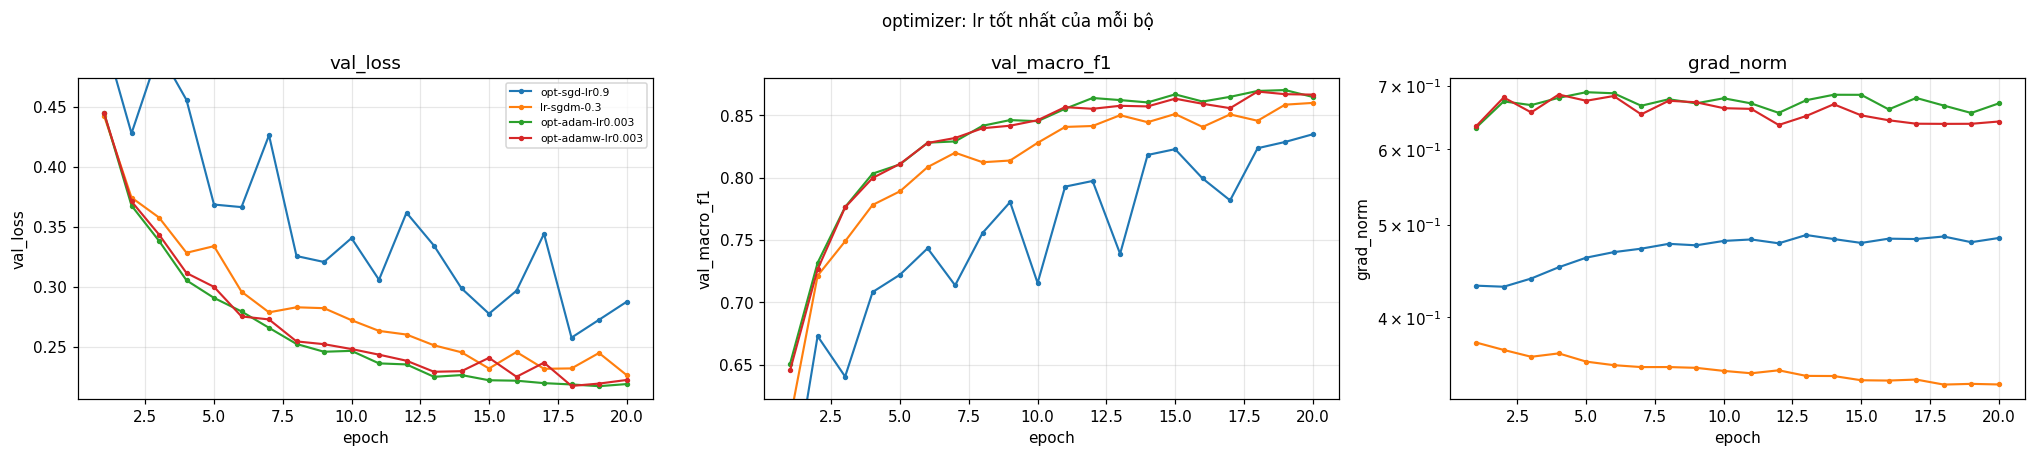

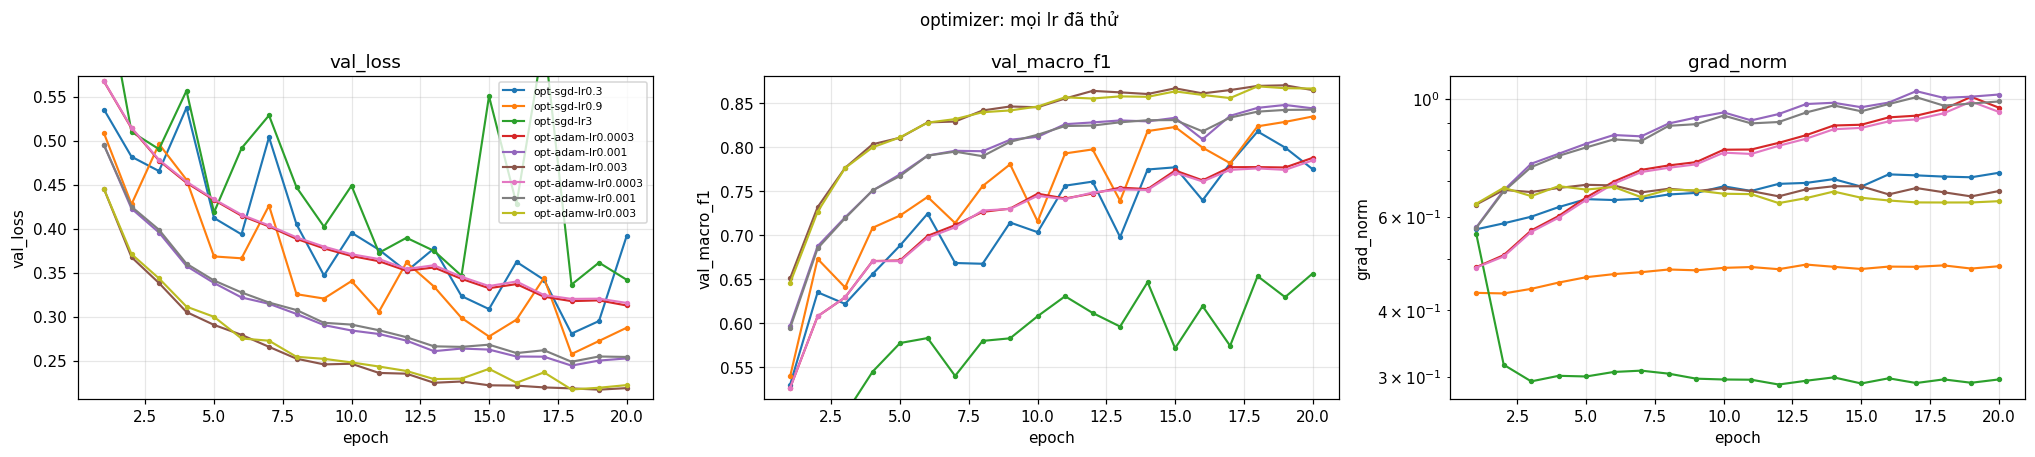

In [14]:
opt_runs = []
for m in (1, 3, 10):
    opt_runs.append(run({"exp_id": f"opt-sgd-lr{LR * m:g}", "group": "optimizer", "optimizer": "sgd", "lr": LR * m,
                         "description": f"SGD thuần (không momentum) lr={LR * m:g}"}, note="Dự đoán: ~10x chậm hơn SGD+momentum cùng lr"))
for lr in (3e-4, 1e-3, 3e-3):
    opt_runs.append(run({"exp_id": f"opt-adam-lr{lr:g}", "group": "optimizer", "optimizer": "adam", "lr": lr,
                         "description": f"Adam (b1=.9, b2=.999, eps=1e-8) lr={lr:g}"}, note="Dự đoán: nhanh hơn SGD+mom ở lr tốt nhất"))
for lr in (3e-4, 1e-3, 3e-3):
    opt_runs.append(run({"exp_id": f"opt-adamw-lr{lr:g}", "group": "optimizer", "optimizer": "adamw", "lr": lr, "weight_decay": 0.01,
                         "description": f"AdamW weight_decay=0.01 lr={lr:g}"}, note="Dự đoán: gần như trùng Adam"))
pool = {"sgd": [r for r in opt_runs if r["cfg"]["optimizer"] == "sgd"],
        "sgd_momentum": sweep,                         # đã chạy ở Part 2 (nhóm hparam), dùng lại làm tham chiếu
        "adam": [r for r in opt_runs if r["cfg"]["optimizer"] == "adam"],
        "adamw": [r for r in opt_runs if r["cfg"]["optimizer"] == "adamw"]}
best_opt = {k: max(v, key=lambda r: np.nan_to_num(r["summary"]["val_macro_f1"], nan=-1)) for k, v in pool.items()}
print(table(opt_runs, REF))
print("\nLr tốt nhất của từng bộ tối ưu (theo val macro-F1):")
print(table(list(best_opt.values()), REF))
plot_compare(list(best_opt.values()), ["val_loss", "val_macro_f1", "grad_norm"], f"{OUT_DIR}/figures/compare_optimizer.png", "optimizer: lr tốt nhất của mỗi bộ")
plot_compare(opt_runs, ["val_loss", "val_macro_f1", "grad_norm"], f"{OUT_DIR}/figures/compare_optimizer-lr.png", "optimizer: mọi lr đã thử")
display(Image(f"{OUT_DIR}/figures/compare_optimizer.png")); display(Image(f"{OUT_DIR}/figures/compare_optimizer-lr.png"))

**Đối chiếu `optimizer`:** ở lr tốt nhất của mỗi bộ (val macro-F1, seed 1): SGD 0.8236 (lr 0.9), SGD+momentum 0.8599 (lr 0.3), Adam 0.8702 (lr 3e-3), AdamW 0.8690 (lr 3e-3). Adam hơn SGD+momentum 0.0103, vượt 2σ = 0.0064 một chút, nhưng **cả hai đều đạt tốt nhất ở mép trên lưới lr** nên chưa đủ để kết luận Adam "thắng"; chỉ có thể nói Adam đạt F1 tương đương hoặc nhỉnh hơn với một lưới lr đã thử. AdamW ≈ Adam (chênh −0.0012, nhỏ hơn nhiễu) đúng dự đoán vì `weight_decay = 0.01` rất nhỏ trong 20 epoch. SGD thuần kém SGD+momentum 0.036 và không đạt được mức tương đương ở lr 3 (F1 0.653), khớp việc momentum tăng bước hiệu dụng nhưng không chứng minh được hệ số 10×. Dự đoán "Adam ít nhạy với lr hơn" **không được ủng hộ**: Adam đi từ 0.788 (3e-4) đến 0.870 (3e-3), biên độ cỡ SGD+momentum trên cùng khoảng 10× lr (0.820 → 0.860 cho 0.03 → 0.3). Adam chậm hơn khoảng 12% mỗi epoch (1.37 s so với 1.22 s).

### Nhóm `dropout` — q ∈ {0.1, 0.3, 0.5}
**Dự đoán trước:** ở baseline mô hình chưa quá khớp (train loss ≈ val loss, cả hai còn giảm sau 20 epoch), nên dropout không giúp mà làm *thiếu khớp nặng hơn*: q càng lớn, val macro-F1 càng thấp và train loss (đo ở eval mode) càng cao; khoảng cách train–val không đổi đáng kể vì nó vốn đã nhỏ. Dropout chỉ là thuốc khi có quá khớp.

drop-0.1                   best_ep=  20 val_loss=0.2403 acc=0.9014 F1=0.8411 | 1.3s/ep 
drop-0.3                   best_ep=  20 val_loss=0.3143 acc=0.8704 F1=0.7751 | 1.3s/ep 
drop-0.5                   best_ep=  20 val_loss=0.4186 acc=0.8247 F1=0.6548 | 1.4s/ep 
  exp_id          opt  lr  best_ep  val_loss  val_acc  val_f1   t_ep  diverged  ΔF1 vs base > 2σ?
 base-s1 sgd_momentum 0.3       20    0.2263   0.9127  0.8599 1.2188     False      -0.0017 Không
drop-0.1 sgd_momentum 0.3       20    0.2403   0.9014  0.8411 1.3446     False      -0.0205    Có
drop-0.3 sgd_momentum 0.3       20    0.3143   0.8704  0.7751 1.3253     False      -0.0865    Có
drop-0.5 sgd_momentum 0.3       20    0.4186   0.8247  0.6548 1.3566     False      -0.2068    Có

khoảng cách val_loss − train_loss ở epoch cuối: {'base-s1': 0.0281, 'drop-0.1': 0.013, 'drop-0.3': 0.004, 'drop-0.5': 0.0028}


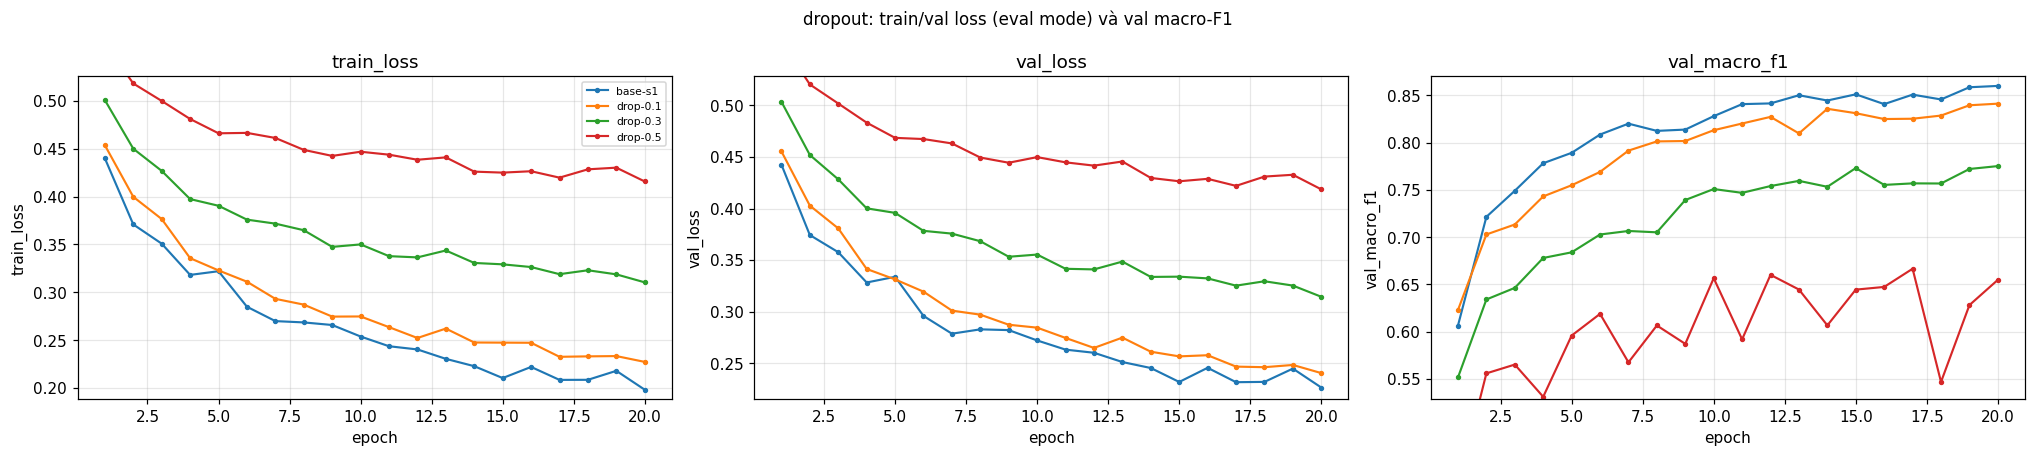

In [15]:
dr = [run({"exp_id": f"drop-{q:g}", "group": "dropout", "dropout": q, "description": f"Dropout q={q:g} sau mỗi ReLU lớp ẩn"},
          note="Dự đoán: không giúp vì chưa quá khớp; q lớn càng hại") for q in (0.1, 0.3, 0.5)]
print(table([base[0]] + dr, REF))
gap = lambda r: r["summary"]["final_val_loss"] - r["summary"]["final_train_loss"]
print("\nkhoảng cách val_loss − train_loss ở epoch cuối:", {r["cfg"]["exp_id"]: round(gap(r), 4) for r in [base[0]] + dr})
plot_compare([base[0]] + dr, ["train_loss", "val_loss", "val_macro_f1"], f"{OUT_DIR}/figures/compare_dropout.png", "dropout: train/val loss (eval mode) và val macro-F1")
display(Image(f"{OUT_DIR}/figures/compare_dropout.png"))

**Đối chiếu `dropout`:** khớp dự đoán. val macro-F1 giảm đơn điệu theo q: 0.8411 (0.1), 0.7751 (0.3), 0.6548 (0.5), so với baseline 0.8616 ± 0.0032; cả ba đều dưới ngưỡng nhiễu. Khoảng cách val − train loss ở epoch cuối thu hẹp (0.028 → 0.013 → 0.004 → 0.003) nhưng val loss lại tăng (0.2263 → 0.2403 → 0.3143 → 0.4186): mô hình vốn chưa quá khớp nên dropout chỉ làm thiếu khớp nặng hơn (train loss ở eval mode cũng tăng). best epoch = 20 ở mọi q, tức vẫn còn học. Dropout chỉ là thuốc khi có quá khớp rõ (val loss tăng trở lại), không có trong thiết lập này.

### Nhóm `clipping` — cắt gradient theo chuẩn L2 toàn cục
Ngưỡng `c` chọn từ `grad_norm` của baseline: lấy **trung vị `grad_norm` theo bước** của `base-s1` (`gn_p50`), nên clipping thực sự kích hoạt ở khoảng một nửa số bước.
**Dự đoán trước:** (a) ở lr baseline, clip với `c` = trung vị làm giảm bước hiệu dụng nên không cải thiện, có thể chậm hơn chút (chênh lệch nhỏ, cỡ nhiễu); (b) phản chứng: tăng lr ×10 và ×30 — không clip sẽ dao động/phân kỳ (gai `grad_norm`), còn clip với cùng lr giữ huấn luyện ổn định vì chặn các bước cực lớn; đây mới là tình huống clipping dùng cho.

baseline: grad_norm theo bước p50 = 0.347, p95 = 0.428, max = 2.844  =>  c = 0.35
clip-c0.35-lr0.3           best_ep=  20 val_loss=0.2275 acc=0.9115 F1=0.8523 | 1.2s/ep 
clip-none-lr3              best_ep=  17 val_loss=1.2090 acc=0.4876 F1=0.0936 | 1.2s/ep 
clip-c0.35-lr3             best_ep=  10 val_loss=0.9724 acc=0.5228 F1=0.1920 | 1.3s/ep 
clip-none-lr9              best_ep=  18 val_loss=1.2313 acc=0.4876 F1=0.0936 | 1.2s/ep 
clip-c0.35-lr9             best_ep=  15 val_loss=1.2449 acc=0.3646 F1=0.0763 | 1.2s/ep 

          exp_id          opt  lr  best_ep  val_loss  val_acc  val_f1   t_ep  diverged  ΔF1 vs base > 2σ?
         base-s1 sgd_momentum 0.3       20    0.2263   0.9127  0.8599 1.2188     False      -0.0017 Không
clip-c0.35-lr0.3 sgd_momentum 0.3       20    0.2275   0.9115  0.8523 1.2158     False      -0.0093    Có
   clip-none-lr3 sgd_momentum 3.0       17    1.2090   0.4876  0.0936 1.2047     False      -0.7679    Có
  clip-c0.35-lr3 sgd_momentum 3.0       10    0.9724 

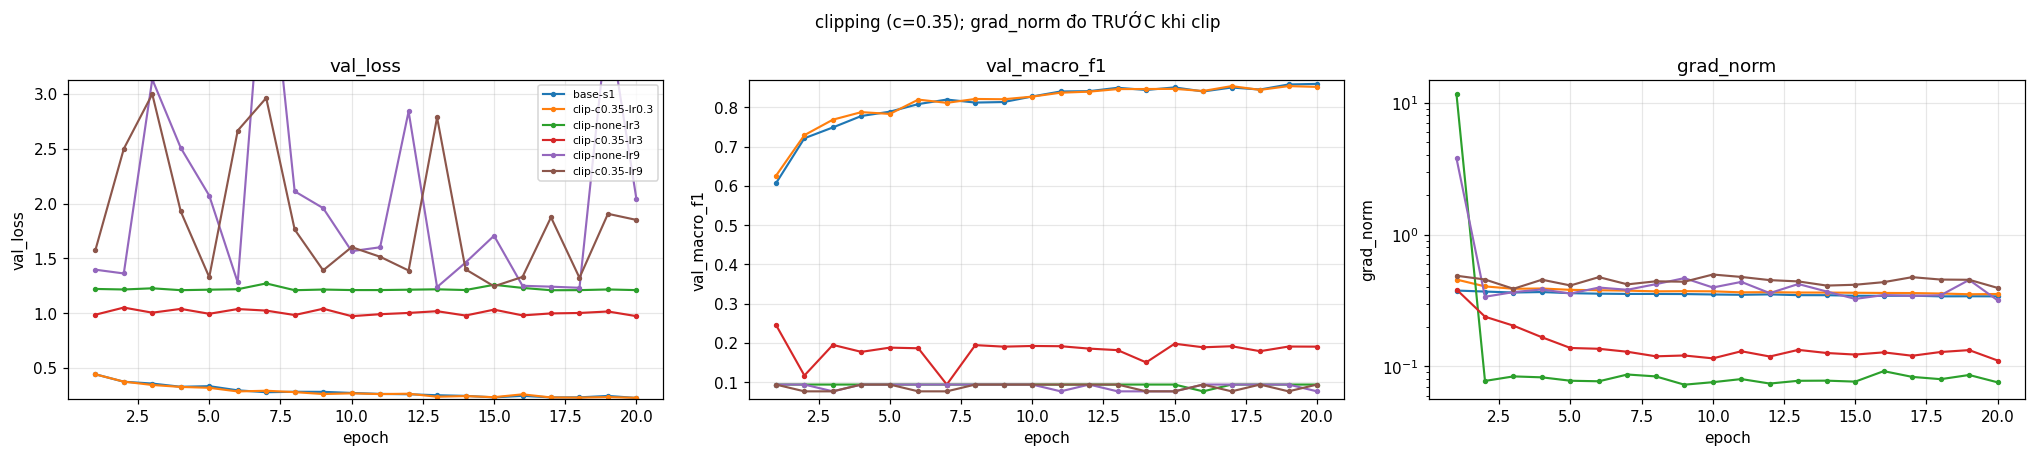

In [16]:
C = float(f"{base[0]['summary']['gn_p50']:.2g}")
print(f"baseline: grad_norm theo bước p50 = {base[0]['summary']['gn_p50']:.3f}, p95 = {base[0]['summary']['gn_p95']:.3f}, max = {base[0]['summary']['gn_max']:.3f}  =>  c = {C:g}")
cl = [run({"exp_id": f"clip-c{C:g}-lr{LR:g}", "group": "clipping", "clip_norm": C, "description": f"Clip c={C:g} ở lr baseline"},
          note="Dự đoán: không giúp ở lr bình thường (chênh lệch cỡ nhiễu)")]
for m in (10, 30):
    cl.append(run({"exp_id": f"clip-none-lr{LR * m:g}", "group": "clipping", "lr": LR * m, "description": f"Không clip, lr x{m} = {LR * m:g}"},
                   note=f"Dự đoán: lr x{m} làm huấn luyện dao động/phân kỳ nếu không clip"))
    cl.append(run({"exp_id": f"clip-c{C:g}-lr{LR * m:g}", "group": "clipping", "lr": LR * m, "clip_norm": C,
                   "description": f"Clip c={C:g}, lr x{m} = {LR * m:g}"}, note=f"Dự đoán: clip cứu được huấn luyện ở lr x{m}"))
print("\n" + table([base[0]] + cl, REF))
print("\ntỉ lệ bước bị cắt (clip_frac) / grad_norm max:", {r["cfg"]["exp_id"]: (round(r["summary"]["clip_frac"], 3), round(r["summary"]["gn_max"], 2)) for r in cl})
plot_compare([base[0]] + cl, ["val_loss", "val_macro_f1", "grad_norm"], f"{OUT_DIR}/figures/compare_clipping.png", f"clipping (c={C:g}); grad_norm đo TRƯỚC khi clip")
display(Image(f"{OUT_DIR}/figures/compare_clipping.png"))

**Đối chiếu `clipping`:** `grad_norm` của baseline có trung vị 0.347, p95 0.428 nhưng max 2.84 (có gai hiếm), nên chọn c = 0.35. (a) Ở lr 0.3, clip c = 0.35 cắt 66% số bước và cho F1 0.8523, thấp hơn trung bình baseline 0.0093 (hơi vượt 2σ = 0.0064): clipping làm giảm bước hiệu dụng, khớp dự đoán là không giúp. (b) Phản chứng ở lr ×10 và ×30: **không clip, mạng sụp** (grad_norm max 7880 ở lr 3 và 966 ở lr 9; sau đó mạng dừng ở mốc đoán đa số (nhiều khả năng do ReLU chết, chưa kiểm tra trực tiếp), val loss 1.209 ≈ entropy phân phối lớp 1.205, F1 0.0936; cờ `diverged` vẫn False vì loss không NaN). **Clip chỉ cứu được một phần ở lr 3** (F1 0.192, acc 0.523, grad_norm max chỉ 3.72) và **không cứu được ở lr 9** (F1 0.0763, val loss dao động 1.3 đến 3). Vậy dự đoán "clip cứu được huấn luyện" chỉ đúng một phần: cả hai lr đã thử quá lớn nên clipping giảm gai nhưng không đủ; chưa thử lr trung gian (khoảng 1) nơi clipping có thể cứu hoàn toàn.

### Nhóm `amp` — mixed precision (FP16 + GradScaler, BF16)
**Dự đoán trước:** tham số vẫn FP32, autocast chỉ hạ độ chính xác của phép nhân ma trận. Mạng này rất nhỏ (48k tham số, batch 512), thời gian bị chi phối bởi chi phí gọi kernel (launch overhead) chứ không phải FLOPs, và autocast còn thêm các phép ép kiểu → **mixed precision không nhanh hơn, có thể chậm hơn**; bộ nhớ cực đại không giảm đáng kể (dữ liệu nằm sẵn trên GPU); độ chính xác ngang FP32 (trong nhiễu seed). Với `M-wide` mức lợi (nếu có) cũng nhỏ. BF16 trên T4 không có phần cứng native nên có thể chậm hơn FP16.

bf16 hỗ trợ: True
amp-fp16                   best_ep=  20 val_loss=0.2246 acc=0.9115 F1=0.8555 | 1.7s/ep 
amp-bf16                   best_ep=  18 val_loss=0.2281 acc=0.9090 F1=0.8519 | 1.5s/ep 
amp-wide-fp16              best_ep=  20 val_loss=0.1985 acc=0.9234 F1=0.8708 | 1.7s/ep 
amp-wide-bf16              best_ep=  18 val_loss=0.2007 acc=0.9211 F1=0.8672 | 1.5s/ep 

       exp_id precision  hidden  val_f1  t_per_epoch_s  peak_mem_MB
      base-s1      fp32 256-128  0.8599         1.2188     174.5771
      hp-wide      fp32 512-256  0.8749         1.2371     192.4614
     amp-fp16      fp16 256-128  0.8555         1.7311     180.1953
     amp-bf16      bf16 256-128  0.8519         1.4960     180.3774
amp-wide-fp16      fp16 512-256  0.8708         1.7132     197.3218
amp-wide-bf16      bf16 512-256  0.8672         1.4916     197.9365


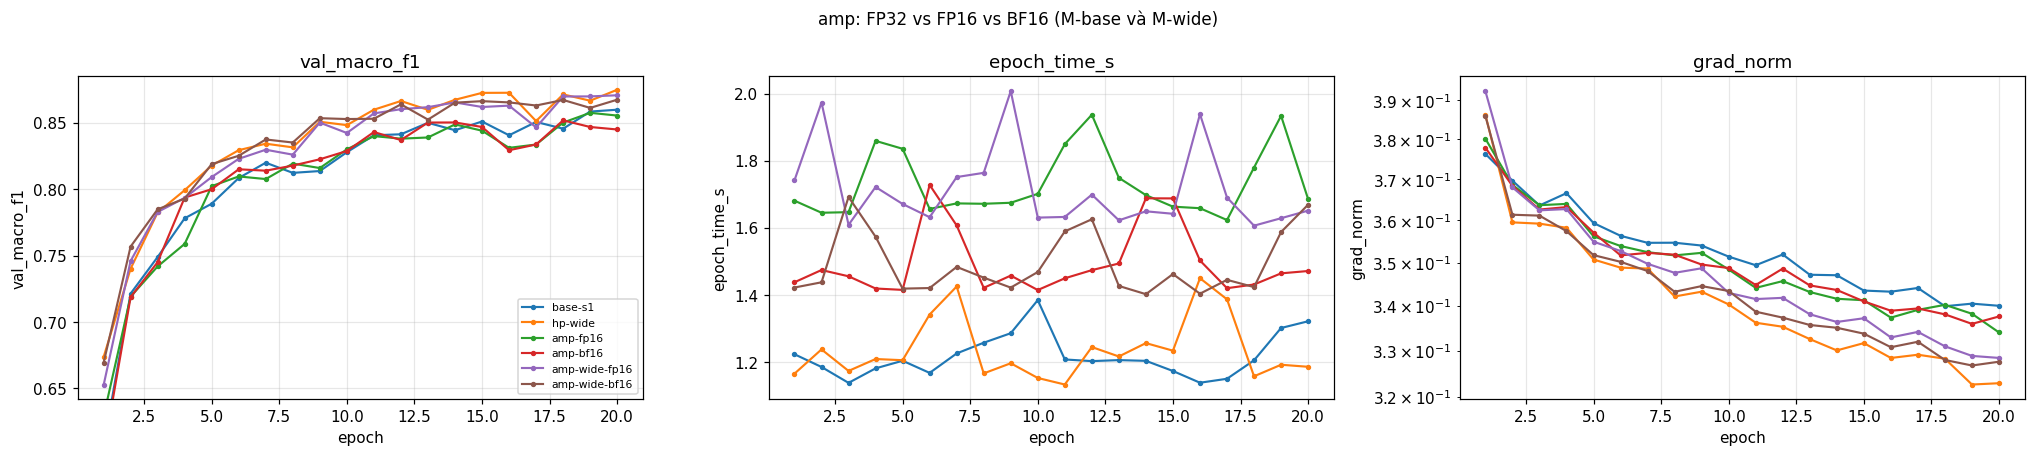

In [17]:
amp, AMP_FAIL = [], {}
print("bf16 hỗ trợ:", torch.cuda.is_bf16_supported() if device == "cuda" else "n/a (không có CUDA)")
for tag, hid, ref_name in (("", (256, 128), "base-s1"), ("wide-", (512, 256), "hp-wide")):
    for prec in ("fp16", "bf16"):
        eid = f"amp-{tag}{prec}"
        try:
            amp.append(run({"exp_id": eid, "group": "amp", "precision": prec, "hidden": hid,
                            "description": f"{prec} autocast{' + GradScaler' if prec == 'fp16' else ''}, {'-'.join(map(str, hid))}; so với {ref_name} (FP32)"},
                           note="Dự đoán: không nhanh hơn (overhead kernel), độ chính xác ngang FP32"))
        except Exception as e:
            AMP_FAIL[eid] = repr(e)[:200]; print(f"{eid}: KHÔNG CHẠY ĐƯỢC -> {AMP_FAIL[eid]}")
cmp_ = [base[0], RESULTS["hp-wide"]] + amp
print("\n" + pd.DataFrame([dict(exp_id=r["cfg"]["exp_id"], precision=r["cfg"]["precision"], hidden="-".join(map(str, r["cfg"]["hidden"])),
                                val_f1=r["summary"]["val_macro_f1"], t_per_epoch_s=r["summary"]["time_per_epoch_s"],
                                peak_mem_MB=r["summary"]["peak_mem_MB"]) for r in cmp_]).round(4).to_string(index=False))
plot_compare(cmp_, ["val_macro_f1", "epoch_time_s", "grad_norm"], f"{OUT_DIR}/figures/compare_amp.png", "amp: FP32 vs FP16 vs BF16 (M-base và M-wide)")
display(Image(f"{OUT_DIR}/figures/compare_amp.png"))

**Đối chiếu `amp`:** khớp dự đoán, mixed precision **không nhanh hơn** mà chậm hơn: M-base 1.22 s/epoch (FP32) → 1.73 s (FP16, +42%) và 1.50 s (BF16, +23%); M-wide 1.24 s → 1.71 s (FP16) và 1.49 s (BF16). Bộ nhớ cực đại không giảm mà tăng nhẹ (175 → 180 MB, ~3%) vì dữ liệu nằm sẵn trên GPU (chiếm phần lớn) và (giả thuyết) autocast giữ thêm bản sao FP16 của trọng số. Cơ chế (giải thích, chưa profile): mạng nhỏ nên thời gian bị chi phối bởi chi phí gọi kernel; autocast thêm phép ép kiểu và GradScaler thêm bước unscale/kiểm tra inf mỗi bước. Độ chính xác thấp hơn FP32 nhẹ nhưng ở cỡ nhiễu: M-base FP16 0.8555 (−0.0061), BF16 0.8519 (−0.0097); M-wide FP16 0.8708 (−0.0041), BF16 0.8672 (−0.0077) so với `hp-wide` 0.8749 (một seed, σ lấy từ baseline). T4 báo `is_bf16_supported() = True` nhưng không có BF16 native nên BF16 chậm hơn FP16 không đáng ngạc nhiên về mặt phần cứng; chưa kiểm chứng bằng profile.

### Nhóm `init` — khởi tạo tham số (baseline dùng He)
**Dự đoán trước:** (a) `zeros`: mọi nơ-ron trong một lớp giống hệt nhau và ReLU(0)=0 nên gradient tới W1, W2, W3 đều bằng 0 (chỉ bias lớp ra có gradient) → mạng không học, chỉ học tần suất lớp: val acc ≈ 0.4876 và macro-F1 ≈ 0.094 (mốc "đoán đa số"), loss bước 0 = ln 7. (b) `normal` (std 0.01): kích hoạt co dần về 0 qua các lớp (std nhỏ) nên gradient của các lớp dưới rất nhỏ → học chậm lúc đầu, kém He sau 20 epoch. (c) `xavier` và `default` (mạng chỉ 3 lớp, nông): gần He, chênh lệch cỡ nhiễu. Loss bước 0 ≈ ln 7 với mọi cách vì logits nhỏ.

init-zeros                 best_ep=  16 val_loss=1.2053 acc=0.4876 F1=0.0936 | 1.2s/ep 
init-normal                best_ep=  19 val_loss=0.2191 acc=0.9137 F1=0.8640 | 1.2s/ep 
init-xavier                best_ep=  18 val_loss=0.2236 acc=0.9117 F1=0.8541 | 1.2s/ep 
init-default               best_ep=  20 val_loss=0.2161 acc=0.9147 F1=0.8613 | 1.3s/ep 
        init  step0_loss  act_std_L1  act_std_L2  act_std_logits  final_grad_norm  val_acc  val_f1
he (base-s1)      2.2691      0.6662      0.6464          0.5934           0.3401   0.9127  0.8599
       zeros      1.9459      0.0000      0.0000          0.0000           0.0363   0.4876  0.0936
      normal      1.9460      0.0346      0.0038          0.0003           0.3382   0.9137  0.8640
      xavier      2.0222      0.2781      0.2203          0.1969           0.3396   0.9117  0.8541
     default      1.9830      0.2753      0.1136          0.0593           0.3418   0.9147  0.8613

(act_std_* = độ lệch chuẩn đầu ra của mỗi nn.Linear ở

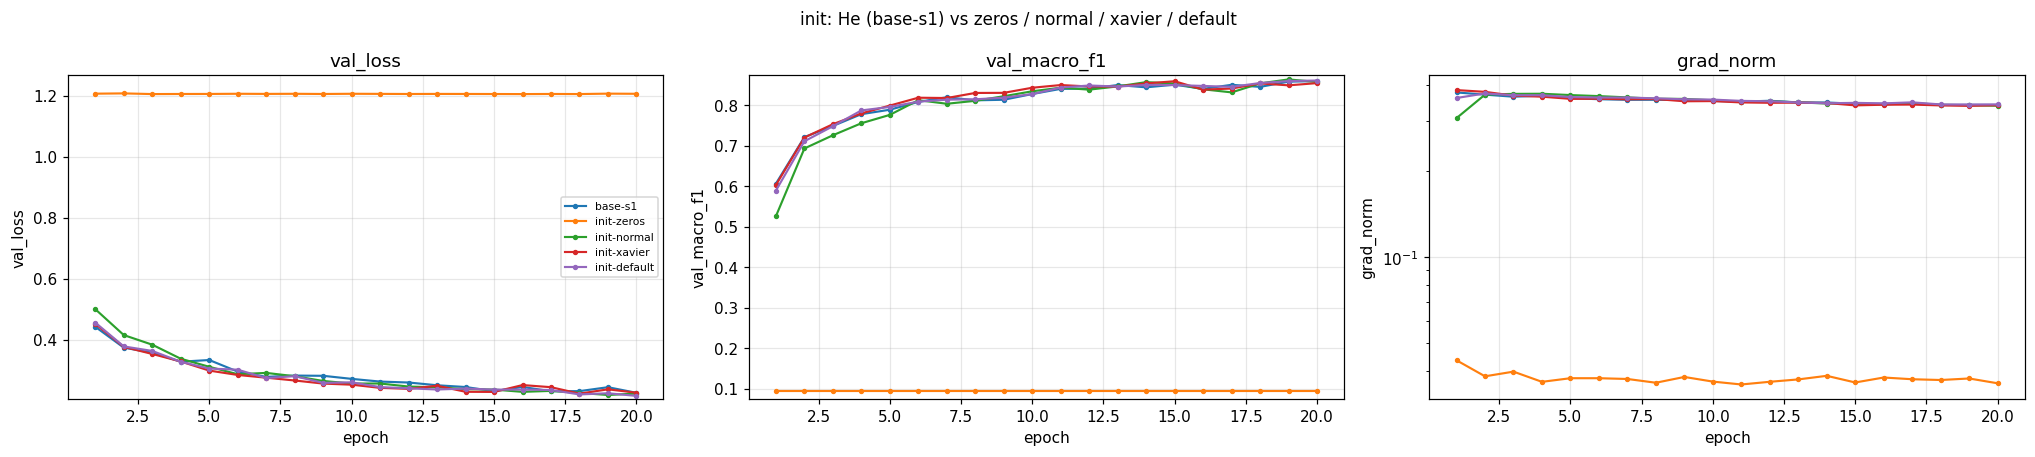

In [18]:
ini = [run({"exp_id": f"init-{n}", "group": "init", "init": n, "description": f"Khởi tạo {n} (bias=0, trừ default)"},
           note={"zeros": "Dự đoán: không học (đối xứng + ReLU(0)), F1≈0.094", "normal": "Dự đoán: học chậm (kích hoạt co về 0)",
                 "xavier": "Dự đoán: gần He", "default": "Dự đoán: gần He"}[n]) for n in ("zeros", "normal", "xavier", "default")]
tab = [dict(init=r["cfg"]["init"], step0_loss=r["summary"]["step0_loss"],
            act_std_L1=r["summary"]["act_std_step0"][0], act_std_L2=r["summary"]["act_std_step0"][1], act_std_logits=r["summary"]["act_std_step0"][2],
            final_grad_norm=r["history"]["grad_norm"][-1], val_acc=r["summary"]["val_acc"], val_f1=r["summary"]["val_macro_f1"]) for r in [base[0]] + ini]
tab[0]["init"] = "he (base-s1)"
print(pd.DataFrame(tab).round(4).to_string(index=False))
print("\n(act_std_* = độ lệch chuẩn đầu ra của mỗi nn.Linear ở bước 0 trên 512 mẫu val; mẫu đầu vào có std ≈", round(data["X_val"][:512].std().item(), 3), ")")
plot_compare([base[0]] + ini, ["val_loss", "val_macro_f1", "grad_norm"], f"{OUT_DIR}/figures/compare_init.png", "init: He (base-s1) vs zeros / normal / xavier / default")
display(Image(f"{OUT_DIR}/figures/compare_init.png"))

**Đối chiếu `init`:** `zeros` đúng dự đoán: mạng không học (val acc 0.4876, F1 0.0936, val loss 1.2053 ≈ entropy phân phối lớp), loss bước 0 = 1.9459 = ln 7, `grad_norm` cuối chỉ 0.036 (chỉ bias lớp ra có gradient vì ReLU(0) = 0 chặn gradient về W1, W2, W3). Dự đoán cho `normal` thì **sai**: dù kích hoạt co rất nhanh qua các lớp (std 0.035 → 0.0038 → 0.0003 ở logits), nó đạt F1 0.8640, ngang hoặc nhỉnh hơn He (baseline 0.8616 ± 0.0032), vì lr 0.3 + momentum đủ lớn để thoát nhanh khỏi vùng gradient nhỏ (`grad_norm` cuối 0.338, giống He 0.340). `xavier` (0.8541, −0.0075) và `default` (0.8613) ở cỡ nhiễu. Kết luận: với mạng chỉ 3 lớp và lr lớn, cách khởi tạo khác nhau không tạo khác biệt có ý nghĩa, trừ khởi tạo đối xứng toàn 0; hiện tượng phương sai kích hoạt biến mất/bùng nổ như biểu đồ 30 lớp trong slide chỉ hiện rõ ở mạng sâu hơn nhiều (chưa thử).

## Part 4 — Cấu hình cuối cùng, đánh giá trên eval, bảng và nộp bài
**Chọn cấu hình cuối CHỈ bằng val.** Bộ tối ưu + lr lấy từ cấu hình `M-base` (batch 512, CE, He, FP32) có val macro-F1 cao nhất trong các lần chạy đã có; sau đó thử 3 ứng viên kết hợp (M-wide, +cosine, +epoch gấp đôi) trên val, chọn ứng viên có val macro-F1 cao nhất rồi chạy 3 seed. Cấu hình cuối đổi nhiều yếu tố cùng lúc (ghi rõ trong `description`).

bộ tối ưu chọn bằng val: {'optimizer': 'adam', 'lr': 0.003, 'weight_decay': 0.0} (từ opt-adam-lr0.003)
final-cand-wide            best_ep=  20 val_loss=0.1783 acc=0.9304 F1=0.8923 | 1.4s/ep 
final-cand-wide-cos        best_ep=  20 val_loss=0.1485 acc=0.9426 F1=0.9116 | 1.5s/ep 
final-cand-wide-cos-40ep   best_ep=  39 val_loss=0.1244 acc=0.9527 F1=0.9243 | 1.5s/ep 

                  exp_id          opt    lr  best_ep  val_loss  val_acc  val_f1   t_ep  diverged  ΔF1 vs base > 2σ?
         final-cand-wide         adam 0.003       20    0.1783   0.9304  0.8923 1.4392     False       0.0307    Có
     final-cand-wide-cos         adam 0.003       20    0.1485   0.9426  0.9116 1.4602     False       0.0500    Có
final-cand-wide-cos-40ep         adam 0.003       39    0.1244   0.9527  0.9243 1.4980     False       0.0627    Có
                 base-s1 sgd_momentum 0.300       20    0.2263   0.9127  0.8599 1.2188     False      -0.0017 Không

cấu hình cuối cùng (chọn bằng val): {'optimizer': '

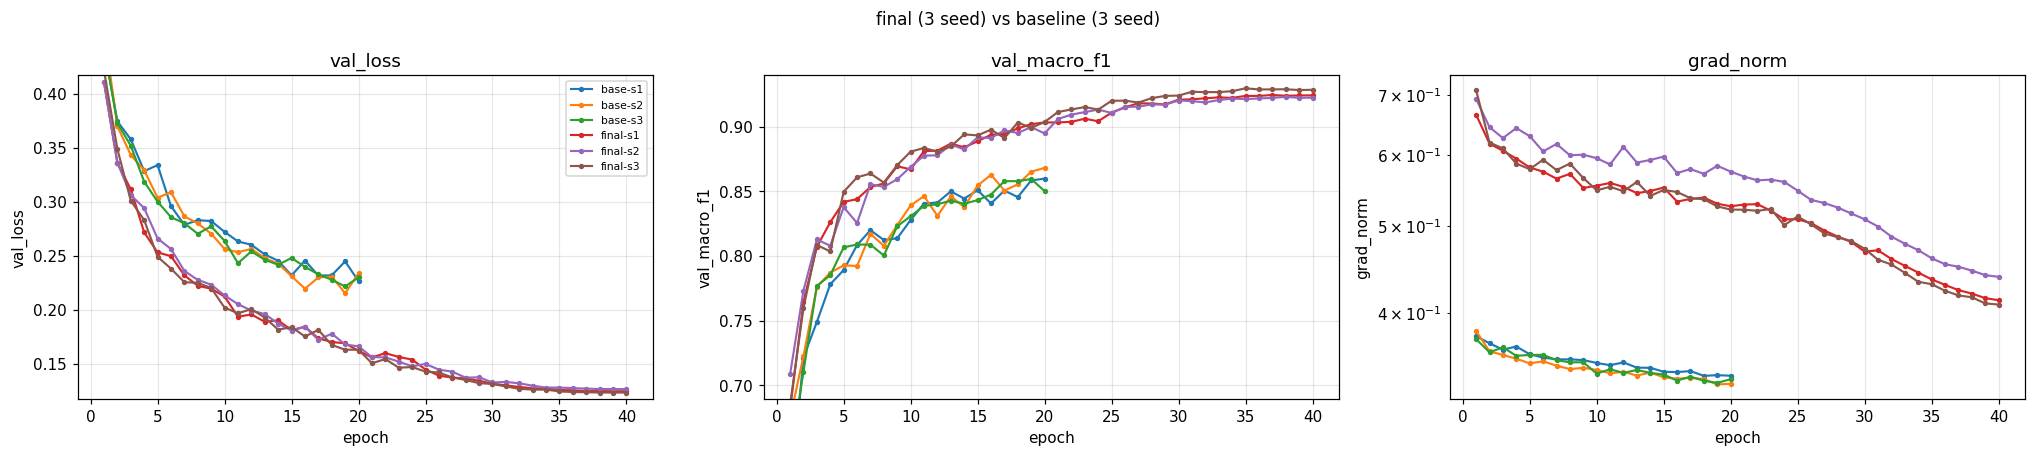

In [19]:
okf = lambda r: np.nan_to_num(r["summary"]["val_macro_f1"], nan=-1)
cand_pool = [r for r in RESULTS.values() if r["cfg"]["hidden"] == (256, 128) and r["cfg"]["batch"] == 512 and r["cfg"]["dropout"] == 0
             and r["cfg"]["clip_norm"] is None and r["cfg"]["precision"] == "fp32" and r["cfg"]["init"] == "he"
             and r["cfg"]["loss"] == "ce" and r["cfg"]["group"] in ("baseline", "optimizer", "hparam")]
top = max(cand_pool, key=okf)["cfg"]
OPT = {k: top[k] for k in ("optimizer", "lr", "weight_decay")}
print(f"bộ tối ưu chọn bằng val: {OPT} (từ {top['exp_id']})")
LONG = 2 * EPOCHS
fcands = [run({"exp_id": "final-cand-wide", "group": "final", **OPT, "hidden": (512, 256),
               "description": f"Ứng viên: {top['optimizer']} + M-wide, {EPOCHS} epoch"}, note="Ứng viên cho cấu hình cuối (chọn bằng val)"),
          run({"exp_id": "final-cand-wide-cos", "group": "final", **OPT, "hidden": (512, 256), "scheduler": "cosine",
               "description": f"Ứng viên: {top['optimizer']} + M-wide + cosine, {EPOCHS} epoch"}, note="Ứng viên cho cấu hình cuối (chọn bằng val)"),
          run({"exp_id": f"final-cand-wide-cos-{LONG}ep", "group": "final", **OPT, "hidden": (512, 256), "scheduler": "cosine", "epochs": LONG,
               "description": f"Ứng viên: {top['optimizer']} + M-wide + cosine, {LONG} epoch"}, note="Ứng viên cho cấu hình cuối (chọn bằng val)")]
print("\n" + table(fcands + [base[0]], REF))
W = max(fcands, key=okf)["cfg"]
FINAL = {k: W[k] for k in ("optimizer", "lr", "weight_decay", "hidden", "scheduler", "epochs", "batch", "dropout", "init", "loss", "clip_norm", "precision")}
print("\ncấu hình cuối cùng (chọn bằng val):", FINAL)
final = [run({"exp_id": f"final-s{s}", "group": "final", **FINAL, "seed": s,
              "description": f"CẤU HÌNH CUỐI, seed {s}: {FINAL['optimizer']} lr={FINAL['lr']:g}, {'-'.join(map(str, FINAL['hidden']))}, {FINAL['scheduler'] or 'lr cố định'}, {FINAL['epochs']} epoch (đổi nhiều yếu tố so với baseline)"},
             need_state=True, note="Cấu hình cuối; đổi nhiều yếu tố so với baseline") for s in (1, 2, 3)]
fF = np.array([r["summary"]["val_macro_f1"] for r in final])
print(f"\nval macro-F1: final = {fF.mean():.4f} ± {fF.std(ddof=1):.4f} | baseline = {F1_MEAN:.4f} ± {SIGMA:.4f} | Δ = {fF.mean() - F1_MEAN:+.4f} (2σ_base = {NOISE:.4f})")
plot_compare(base + final, ["val_loss", "val_macro_f1", "grad_norm"], f"{OUT_DIR}/figures/compare_final.png", "final (3 seed) vs baseline (3 seed)")
display(Image(f"{OUT_DIR}/figures/compare_final.png"))

### Đánh giá trên tập eval (chỉ làm sau khi đã chọn xong cấu hình bằng val)
Nạp `best_state` (epoch val loss thấp nhất), dự đoán TOÀN BỘ `X_eval` ở `eval()`, ghi CSV rồi chấm bằng đúng `scripts/evaluate.py`.
`predictions_eval.csv` và `eval_result.json` nộp là của **`final-s1`**. Các seed còn lại (baseline và final) chỉ để đo nhiễu của điểm eval; dự đoán của chúng ghi tạm rồi xoá, kết quả lưu ở `results/eval_<exp_id>.json`.
Không chỉnh lại cấu hình sau khi thấy điểm eval.

In [20]:
EVAL = {}
pred_path, out_json = f"{OUT_DIR}/predictions_eval.csv", f"{OUT_DIR}/eval_result.json"
final_eval(RESULTS["final-s1"]["cfg"], RESULTS["final-s1"], data, pred_path)
print("=== final-s1 (nộp) ===")
EVAL["final-s1"] = run_evaluate_script(pred_path, out_json, REPO_ROOT)
for eid in ("base-s1", "base-s2", "base-s3", "final-s2", "final-s3"):
    with tempfile.TemporaryDirectory() as td:
        final_eval(RESULTS[eid]["cfg"], RESULTS[eid], data, f"{td}/p.csv")
        EVAL[eid] = run_evaluate_script(f"{td}/p.csv", f"{OUT_DIR}/results/eval_{eid}.json", REPO_ROOT, verbose=False)
ev = pd.DataFrame({k: dict(eval_acc=v["accuracy"], eval_macro_f1=v["macro_f1"], val_macro_f1=RESULTS[k]["summary"]["val_macro_f1"],
                           val_acc=RESULTS[k]["summary"]["val_acc"]) for k, v in EVAL.items()}).T.loc[["base-s1", "base-s2", "base-s3", "final-s1", "final-s2", "final-s3"]]
print("\n" + ev.round(4).to_string())
for name in ("base", "final"):
    x = ev.loc[[i for i in ev.index if i.startswith(name)], "eval_macro_f1"]
    print(f"{name}: eval macro-F1 = {x.mean():.4f} ± {x.std(ddof=1):.4f}")
d = ev.loc[[i for i in ev.index if i.startswith('final')], "eval_macro_f1"].mean() - ev.loc[[i for i in ev.index if i.startswith('base')], "eval_macro_f1"].mean()
print(f"cải thiện eval macro-F1 (final − base, TB 3 seed) = {d:+.4f}; riêng final-s1 − base-s1 = {ev.loc['final-s1','eval_macro_f1'] - ev.loc['base-s1','eval_macro_f1']:+.4f}")
print(f"chênh val − eval (macro-F1), final-s1: {ev.loc['final-s1','val_macro_f1'] - ev.loc['final-s1','eval_macro_f1']:+.4f}")

=== final-s1 (nộp) ===
n_eval = 116203
accuracy = 0.9530
macro_f1 = 0.9277   <- chỉ số chính

lớp  support  precision  recall    f1
  0    42368     0.9545  0.9465  0.9505
  1    56661     0.9558  0.9640  0.9599
  2     7151     0.9525  0.9508  0.9516
  3      549     0.8879  0.8652  0.8764
  4     1899     0.8952  0.8636  0.8791
  5     3473     0.9172  0.9122  0.9147
  6     4102     0.9638  0.9595  0.9616

ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
       0      1     2    3     4     5     6
0  40102   2108     1    0    24     2   131
1   1737  54620    76    0   151    60    17
2      1    107  6799   38    12   194     0
3      0      0    55  475     0    19     0
4     34    201    13    0  1640    11     0
5      4     81   194   22     4  3168     0
6    136     29     0    0     1     0  3936

đã ghi /content/K4-Track4-Day1-Neuralnetwork/submission_MSSV/eval_result.json


          eval_acc  eval_macro_f1  val_macro_f1  val_acc
base-s1     0.9108         0.8616        0

final-s1 (nộp) — chỉ số theo lớp trên eval:
              support  precision  recall      f1
Spruce/Fir     42368     0.9545  0.9465  0.9505
Lodgepole      56661     0.9558  0.9640  0.9599
Ponderosa       7151     0.9525  0.9508  0.9516
Cottonwood       549     0.8879  0.8652  0.8764
Aspen           1899     0.8952  0.8636  0.8791
Douglas-fir     3473     0.9172  0.9122  0.9147
Krummholz       4102     0.9638  0.9595  0.9616

base-s1 — F1 theo lớp: {'Spruce/Fir': 0.9076, 'Lodgepole': 0.9248, 'Ponderosa': 0.9011, 'Cottonwood': 0.7868, 'Aspen': 0.7693, 'Douglas-fir': 0.8148, 'Krummholz': 0.9266}

lớp khó nhất: 3 (Cottonwood), F1 = 0.8764; tỉ lệ dự đoán của các mẫu thuộc lớp này: {'Cottonwood': np.float64(0.865), 'Ponderosa': np.float64(0.1), 'Douglas-fir': np.float64(0.035)}
5 cặp nhầm lẫn nhiều nhất (thật -> dự đoán): [('Spruce/Fir->Lodgepole', 2108), ('Lodgepole->Spruce/Fir', 1737), ('Aspen->Lodgepole', 201), ('Ponderosa->Douglas-fir', 194), ('Douglas-fir->Ponderosa', 194)]


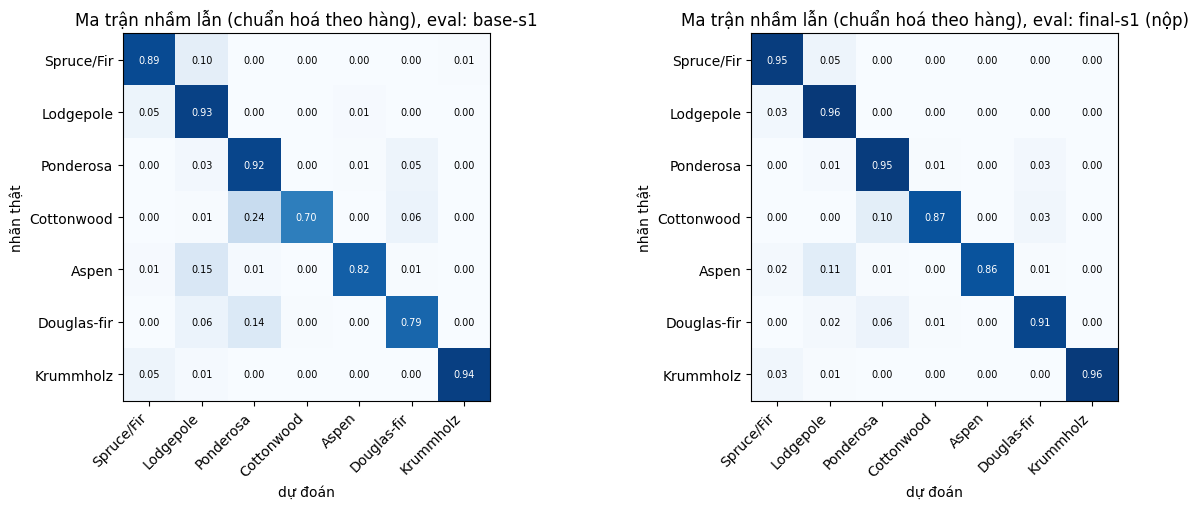

In [21]:
# Phân tích lỗi theo lớp (final-s1 so với base-s1)
NAMES = ["Spruce/Fir", "Lodgepole", "Ponderosa", "Cottonwood", "Aspen", "Douglas-fir", "Krummholz"]
def per_class(e):
    return pd.DataFrame(e["per_class"]).set_index("cls")[["support", "precision", "recall", "f1"]].set_axis(NAMES)
pcf, pcb = per_class(EVAL["final-s1"]), per_class(EVAL["base-s1"])
print("final-s1 (nộp) — chỉ số theo lớp trên eval:\n", pcf.round(4).to_string())
print("\nbase-s1 — F1 theo lớp:", pcb["f1"].round(4).to_dict())
cm = np.array(EVAL["final-s1"]["confusion_matrix"]); cmb = np.array(EVAL["base-s1"]["confusion_matrix"])
worst = int(pcf["f1"].values.argmin()); row = cm[worst] / cm[worst].sum()
print(f"\nlớp khó nhất: {worst} ({NAMES[worst]}), F1 = {pcf['f1'].iloc[worst]:.4f}; tỉ lệ dự đoán của các mẫu thuộc lớp này:",
      {NAMES[j]: round(row[j], 3) for j in np.argsort(-row)[:3]})
off = [(cm[i, j], NAMES[i], NAMES[j]) for i in range(7) for j in range(7) if i != j]
print("5 cặp nhầm lẫn nhiều nhất (thật -> dự đoán):", [(f"{a}->{b}", int(n)) for n, a, b in sorted(off, reverse=True)[:5]])
fig, ax = plt.subplots(1, 2, figsize=(13, 5.2))
for a, (c_, t) in zip(ax, ((cmb, "base-s1"), (cm, "final-s1 (nộp)"))):
    im = a.imshow(c_ / c_.sum(1, keepdims=True), cmap="Blues", vmin=0, vmax=1)
    a.set_xticks(range(7)); a.set_xticklabels(NAMES, rotation=45, ha="right"); a.set_yticks(range(7)); a.set_yticklabels(NAMES)
    a.set_xlabel("dự đoán"); a.set_ylabel("nhãn thật"); a.set_title(f"Ma trận nhầm lẫn (chuẩn hoá theo hàng), eval: {t}")
    for i in range(7):
        for j in range(7): a.text(j, i, f"{c_[i, j] / c_[i].sum():.2f}", ha="center", va="center", fontsize=7, color="white" if c_[i, j] / c_[i].sum() > .5 else "black")
fig.tight_layout(); fig.savefig(f"{OUT_DIR}/figures/compare_confusion.png", dpi=110, bbox_inches="tight"); plt.show()

**Phân tích lỗi (`final-s1`, eval):** macro-F1 = 0.9277, accuracy = 0.9530. Hai lớp khó nhất là hai lớp hiếm: **lớp 3 Cottonwood/Willow** (F1 0.8764, chỉ 549 mẫu eval ≈ 0.47%) và **lớp 4 Aspen** (F1 0.8791, 1 899 mẫu ≈ 1.6%). Cottonwood bị nhầm chủ yếu thành Ponderosa (55/549 = 10.0%) và Douglas-fir (19/549 = 3.5%); Aspen bị nhầm thành Lodgepole (201/1 899 = 10.6%). Các lớp lớn đều 0.95 đến 0.96, nhưng cặp nhầm lẫn lớn nhất về số mẫu là Spruce/Fir ↔ Lodgepole (2 108 và 1 737 mẫu), tức hai lớp chiếm 85% dữ liệu bị lẫn vào nhau (khoảng 5% và 3% mỗi lớp). Cặp Ponderosa ↔ Douglas-fir nhầm đối xứng (194 và 194 mẫu). So với baseline `base-s1`, các lớp hiếm cải thiện nhiều nhất: Cottonwood 0.787 → 0.876, Aspen 0.769 → 0.879, Douglas-fir 0.815 → 0.915 (+0.09 đến +0.11) so với +0.035 đến +0.05 ở các lớp còn lại, nên phần lớn lợi ích của mô hình rộng, Adam và cosine đến từ lớp hiếm. Lý giải: số mẫu ít (lớp 3 chỉ 0.47%) và các lớp gần nhau trong không gian đặc trưng bị lẫn (giả thuyết hợp lý về địa hình/độ cao, **chưa kiểm chứng** vì ta chưa phân tích đặc trưng). Cách cải thiện sẽ thử: loss có trọng số theo lớp hoặc lấy mẫu lại cho lớp hiếm, và huấn luyện lâu hơn (best epoch của `final-s1` là 39/40; cosine đưa lr về 0 nên khó nói còn giảm tiếp hay không, cần chạy thêm để biết).

In [22]:
# Bảng experiments.xlsx từ results/*.json (đọc lại từ đĩa để chắc chắn JSON đủ thông tin)
SUMMARY_NOTES = {}      # nhận xét ngắn theo nhóm cho sheet Summary; được viết trực tiếp vào experiments.xlsx sau khi có kết quả
disk = {r["cfg"]["exp_id"]: r for r in load_results(f"{OUT_DIR}/results")}
rows = [to_row(disk[eid], EVAL.get(eid), NOTES.get(eid, "")) for eid in RESULTS if eid in disk]
write_xlsx(rows, f"{REPO_ROOT}/templates/experiment_table_template.xlsx", f"{OUT_DIR}/experiments.xlsx",
           seed_ids=["base-s1", "base-s2", "base-s3"], summary_notes=SUMMARY_NOTES)
figs = sorted(f for f in os.listdir(f"{OUT_DIR}/figures") if f.endswith(".png") and not f.startswith("compare_"))
assert sorted(r["figure_file"].split("/")[-1] for r in rows) == figs, "mỗi dòng bảng phải có đúng một ảnh figures/<exp_id>.png"
print(f"experiments.xlsx: {len(rows)} dòng, {len(figs)} ảnh thí nghiệm, {len([f for f in os.listdir(f'{OUT_DIR}/figures') if f.startswith('compare_')])} ảnh compare_*")
print(pd.Series([r["group"] for r in rows]).value_counts().to_dict())
print(f"Tổng thời gian notebook: {(time.time() - T_START) / 60:.1f} phút")

experiments.xlsx: 47 dòng, 47 ảnh thí nghiệm, 12 ảnh compare_*
{'hparam': 10, 'optimizer': 9, 'final': 6, 'clipping': 5, 'amp': 4, 'init': 4, 'dropout': 3, 'baseline': 3, 'loss': 3}
Tổng thời gian notebook: 24.9 phút


**Hết notebook.** Xem `../REPORT.md` cho báo cáo kết luận.